In [39]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study5.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
outputdirCleaned = os.path.join(topdir, f'data/{study}/Cleaned')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'fertility_score', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_stripes', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'cogpro_predict', 'cogpro_explain', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'stripes_low', 'stripes_high', 'feet_low', 'feet_discrete_slider.response', 'feet_direction_slider.response', 'feet_continuous_slider.response', 'feet_discrete_slider_mid.response', 'feet_direction_slider_mid.response', 'feet_continuous_slider_mid.response', 'stripes_discrete_slider.response', 'stripes_direction_slider.response', 'stripes_continuous_slider.response', 'stripes_discrete_slider_mid.response', 'stripes_direction_slider_mid.response', 'stripes_continuous_slider_mid.response', 'task']
Predict columns: ['participant', 'training_responses', 'fertility_score', 'error', 'feedback', 'trial_stop_time', 'testing_image

Data Processing (fix string representations of lists)

In [40]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_feet', 'training_stripes', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['fertility_score'] = df_accommodate['fertility_score'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['fertility_score'] = df_predict['fertility_score'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
df_combined['participant'] = range(1, len(df_combined) + 1)



Sanity Checks

In [41]:
print(df_combined['task'].value_counts())

task
accommodate    293
predict        293
Name: count, dtype: int64


In [ ]:
#Distribution of clicks

In [42]:
feedback_by_condition = (
    df_combined
    .loc[df_combined['feedback'].notna(), ['task', 'participant', 'feedback']]
    .sort_values(['task', 'participant'])
)

for task, sub in feedback_by_condition.groupby('task'):
    print(f"\n\n=== {task.upper()} ===")
    for _, row in sub.iterrows():
        print(f"\nParticipant {row['participant']}:")
        print(row['feedback'])



=== ACCOMMODATE ===

Participant 1:
['There did not appear to be sufficient information to reliably determine which factors caused an exact Fertility score.\xa0In addition, the instructions mentioned season is a factor for Fertility, but season is not presented in the survey.']

Participant 2:
[]

Participant 3:
['Initially the instructions were unclear, I think if a side by side of the different traits was shown before the survey it would have been easier to differentiate them immediately instead of second guessing if they were truly different a few questions in.\xa0I did catch onto a pattern after seeing a few rounds about which trait was more beneficial.\xa0']

Participant 4:
[]

Participant 5:
[]

Participant 6:
['I made my decision depending on the consistency I found on certain features']

Participant 7:
[]

Participant 8:
['I made my decision based on the features whether it had curved toes or not']

Participant 9:
['The main specific trait that ultimately mattered the most wa

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6381/2174187515.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6381/2174187515.py:26: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


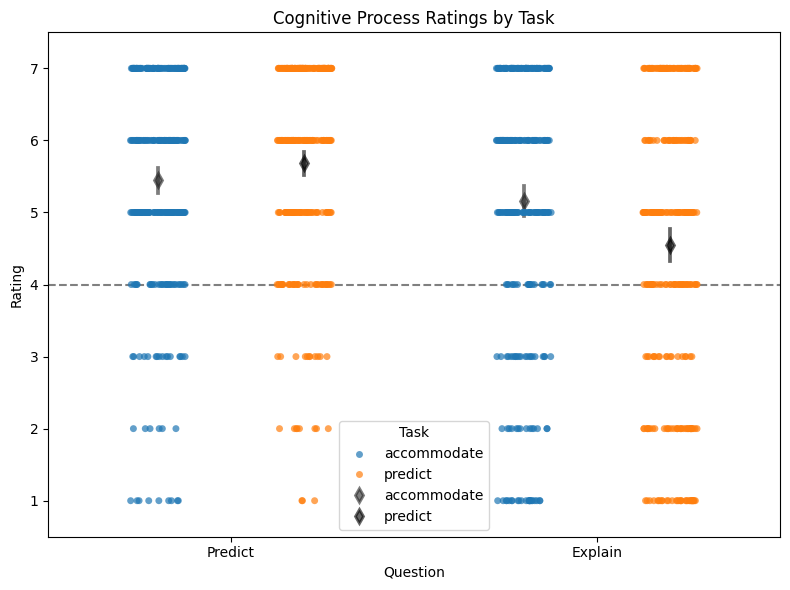

In [43]:

# long format for plotting
df_cogpro_long = df_combined.melt(
    id_vars=['participant', 'task'],
    value_vars=['cogpro_predict', 'cogpro_explain'],
    var_name='question',
    value_name='rating'
)

df_cogpro_long['question'] = df_cogpro_long['question'].replace({
    'cogpro_predict': 'Predict',
    'cogpro_explain': 'Explain'
})

plt.figure(figsize=(8,6))

sns.stripplot(
    data=df_cogpro_long,
    x='question',
    y='rating',
    hue='task',
    dodge=True,
    jitter=.15,
    alpha=.7
)

sns.pointplot(
    data=df_cogpro_long,
    x='question',
    y='rating',
    hue='task',
    dodge=.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=.6
)

plt.ylim(.5, 7.5)
plt.axhline(4, color='gray', linestyle='--')
plt.title('Cognitive Process Ratings by Task')
plt.ylabel('Rating')
plt.xlabel('Question')
plt.legend(title='Task')
plt.tight_layout()

#plt.savefig(os.path.join(outputdir, 'CogProRatingsByTask.png'), dpi=300)
plt.show()

In [44]:
#Look at fertility score in training by participant/category in accomodate task
df = df_accommodate[['participant', 'training_categories', 'fertility_score']]
df_long = (
    df
    .explode(['training_categories', 'fertility_score'])
    .rename(columns={'training_categories': 'category'})
)
avg_fertility = (
    df_long
    .groupby(['category'], as_index=False)
    ['fertility_score']
    .mean()
)
print(avg_fertility)

  category fertility_score
0     high          7.3093
1      low        3.575085


In [45]:
#Look at fertility score in training by participant/category in predict task
df = df_predict[['participant', 'training_categories', 'fertility_score']]
df_long = (
    df
    .explode(['training_categories', 'fertility_score'])
    .rename(columns={'training_categories': 'category'})
)
avg_fertility = (
    df_long
    .groupby(['category'], as_index=False)
    ['fertility_score']
    .mean()
)
print(avg_fertility)

  category fertility_score
0     high          7.3093
1      low        3.575085


In [46]:
#Overall means by category in accommodate task (participant responses)
df = df_accommodate[['participant', 'testing_categories', 'testing_responses']]
df_long = (
    df
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category'})
)
#print(df_long)
avg_rating = (
    df_long
    .groupby(['category'], as_index=False)
    ['testing_responses']
    .mean()
)
print(avg_rating)

  category testing_responses
0     high          7.254266
1      low          4.254266


In [47]:
#Overall means by actual testing category in prediction task
df = df_predict[['participant', 'testing_categories', 'testing_responses']]
df_long = (
    df
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category'})
)
#print(df_long)
avg_rating = (
    df_long
    .groupby(['category'], as_index=False)
    ['testing_responses']
    .mean()
)
print(avg_rating)

  category testing_responses
0     high          7.197952
1      low          4.204778


Timing

task
accommodate    669.967086
predict        497.715163
Name: trial_stop_time, dtype: float64


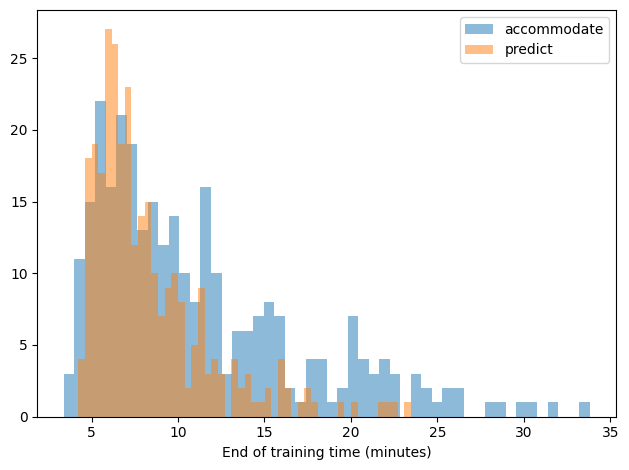

In [48]:
#Look at average time across task
df_combined['trial_stop_time'].describe()
avg_time = df_combined.groupby(['task'])['trial_stop_time'].mean()
print(avg_time)

for task, subdf in df_combined.groupby('task'):
    plt.hist(
        subdf['trial_stop_time']/60,
        bins=50,
        alpha=0.5,
        label=task
    )

plt.xlabel('End of training time (minutes)')
plt.legend()
plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure1TrialStopTimeByTask.png'))
plt.show()


**Primary Analysis #1**

Part 1: Model Parameter Score Complexity across conditions

In [49]:
import pandas as pd
from scipy.stats import chi2_contingency

all_participant_rows = []
for suffix, time in [('', 'end'), ('_mid', 'mid')]:

    participant_rows = []

    for _, row in df_combined.iterrows():

        feet_yes = (
            1 if str(row[f'feet_discrete_slider{suffix}.response']).strip() == 'Yes'
            else 0
        )

        stripes_yes = (
            1 if str(row[f'stripes_discrete_slider{suffix}.response']).strip() == 'Yes'
            else 0
        )

        model_param_score = feet_yes + stripes_yes

        participant_rows.append({
            'participant': row['participant'],
            'task': row['task'],
            'time': time,
            'model_param_score': model_param_score,
            'conditionOrder': row['conditionOrder'],

            'relevant_dim': row['relevant_dim'],
            'irrelevant_dim': row['irrelevant_dim'],

            'feet_high': row['feet_high'],
            'stripes_high': row['stripes_high'],
            'feet_low': row['feet_low'],
            'stripes_low': row['stripes_low'],

            f'feet_discrete_slider.{suffix}.response': row[f'feet_discrete_slider{suffix}.response'],
            f'stripes_discrete_slider.{suffix}.response': row[f'stripes_discrete_slider{suffix}.response'],

            'feet_reported_relevant': feet_yes,
            'stripes_reported_relevant': stripes_yes,

            'cogpro_explain': row['cogpro_explain'],
            'cogpro_predict': row['cogpro_predict'],

            'overfit': model_param_score == 2
        })

    df_params = pd.DataFrame(participant_rows)
    all_participant_rows.extend(participant_rows)

    contingency = pd.crosstab(
        df_params['task'],
        df_params['overfit']
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    label = "END" if suffix == "" else "MID"

    print(f"\n{'='*40}")
    print(f"{label} RESPONSES")
    print(f"{'='*40}")

    print(contingency)
    print(f"\nChi-square = {chi2:.3f}")
    print(f"df = {dof}")
    print(f"p-value = {p:.4f}")
df_params_all = pd.DataFrame(all_participant_rows)


END RESPONSES
overfit      False  True 
task                     
accommodate     93    200
predict        104    189

Chi-square = 0.765
df = 1
p-value = 0.3819

MID RESPONSES
overfit      False  True 
task                     
accommodate    145    148
predict        128    165

Chi-square = 1.756
df = 1
p-value = 0.1852


  time         task irrelevant_dim      mean  sum  count  overfit_percent
0  end  accommodate           feet  0.691781  101    146        69.178082
1  end  accommodate        stripes  0.673469   99    147        67.346939
2  end      predict           feet  0.657534   96    146        65.753425
3  end      predict        stripes  0.632653   93    147        63.265306
4  mid  accommodate           feet  0.513699   75    146        51.369863
5  mid  accommodate        stripes  0.496599   73    147        49.659864
6  mid      predict           feet  0.582192   85    146        58.219178
7  mid      predict        stripes  0.544218   80    147        54.421769


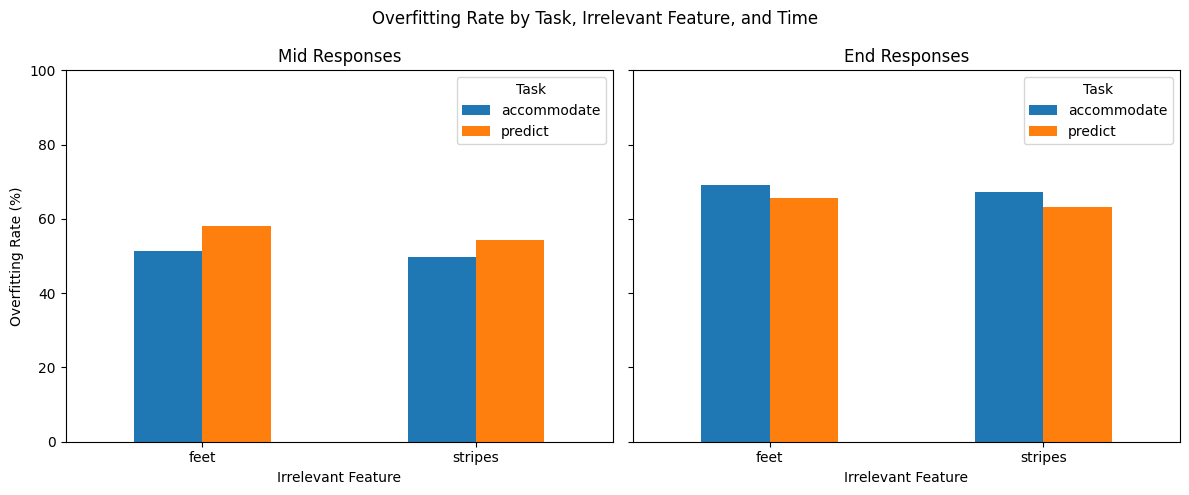

In [50]:
import matplotlib.pyplot as plt

overfit_summary = (
    df_params_all
    .groupby(['time', 'task', 'irrelevant_dim'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_summary['overfit_percent'] = overfit_summary['mean'] * 100

print(overfit_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, time_label in zip(axes, ['mid', 'end']):

    plot_data = (
        overfit_summary[overfit_summary['time'] == time_label]
        .pivot(
            index='irrelevant_dim',
            columns='task',
            values='overfit_percent'
        )
    )

    plot_data.plot(kind='bar', ax=ax)

    ax.set_title(f'{time_label.capitalize()} Responses')
    ax.set_xlabel('Irrelevant Feature')
    ax.set_ylabel('Overfitting Rate (%)')
    ax.set_ylim(0, 100)
    ax.legend(title='Task')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Overfitting Rate by Task, Irrelevant Feature, and Time')
plt.tight_layout()
plt.show()

In [51]:
#Reference Levels
df_params_all['overfit_binary'] = (
    df_params_all['overfit']
    .astype(int)
)
df_params_all['task'] = pd.Categorical(
    df_params_all['task'],
    categories=['predict', 'accommodate']
)

df_params_all['irrelevant_dim'] = pd.Categorical(
    df_params_all['irrelevant_dim'],
    categories=['stripes', 'feet']  
)

df_params_all['time'] = pd.Categorical(
    df_params_all['time'],
    categories=['mid', 'end']
)

# Logistic regression:
# overfit = 1 if model_param_score == 2, else 0
model_overfit_time = smf.logit(
    formula='overfit_binary ~ task * irrelevant_dim * time',
    data=df_params_all
).fit()

print(model_overfit_time.summary())

Optimization terminated successfully.
         Current function value: 0.663048
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:         overfit_binary   No. Observations:                 1172
Model:                          Logit   Df Residuals:                     1164
Method:                           MLE   Df Model:                            7
Date:                Thu, 11 Jun 2026   Pseudo R-squ.:                 0.01541
Time:                        09:09:56   Log-Likelihood:                -777.09
converged:                       True   LL-Null:                       -789.25
Covariance Type:            nonrobust   LLR p-value:                 0.0009996
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept           

  explain_group irrelevant_dim      mean  sum  count  overfit_percent
0  High explain           feet  0.400000    6     15        40.000000
1  High explain        stripes  0.416667    5     12        41.666667
2   Low explain           feet  0.400000    2      5        40.000000
3   Low explain        stripes  0.500000    4      8        50.000000


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_51179/643424755.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['explain_group', 'irrelevant_dim'])['overfit']


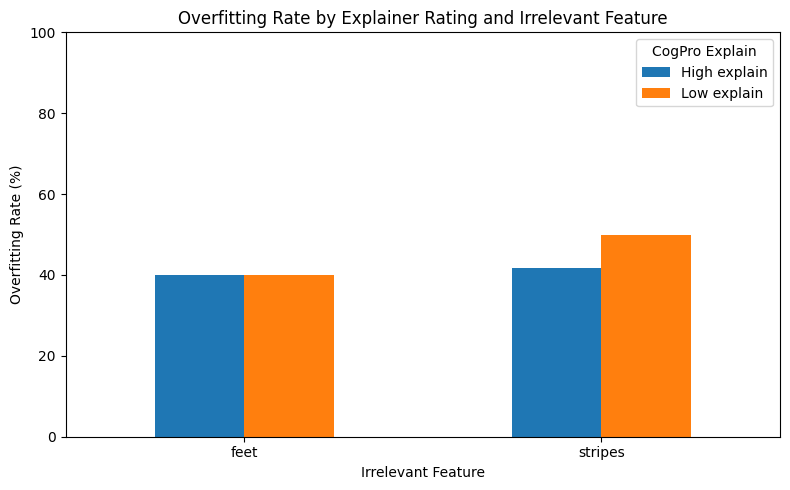

In [38]:
# High/low explainer rating
df_params['explain_group'] = np.where(
    df_params['cogpro_explain'] >= 4,
    'High explain',
    'Low explain'
)

# Overfitting rate by explain group and irrelevant feature
overfit_explain_summary = (
    df_params
    .groupby(['explain_group', 'irrelevant_dim'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_explain_summary['overfit_percent'] = overfit_explain_summary['mean'] * 100

print(overfit_explain_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = overfit_explain_summary.pivot(
    index='irrelevant_dim',
    columns='explain_group',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Explainer Rating and Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='CogPro Explain')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'OverfittingRateByCogProExplainanddim.png'), dpi=300)
plt.show()

  explain_group         task      mean  sum  count  overfit_percent
0  High explain      predict  0.333333    4     12        33.333333
1  High explain  accommodate  0.466667    7     15        46.666667
2   Low explain      predict  0.500000    4      8        50.000000
3   Low explain  accommodate  0.400000    2      5        40.000000


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_51179/1428687838.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['explain_group', 'task'])['overfit']


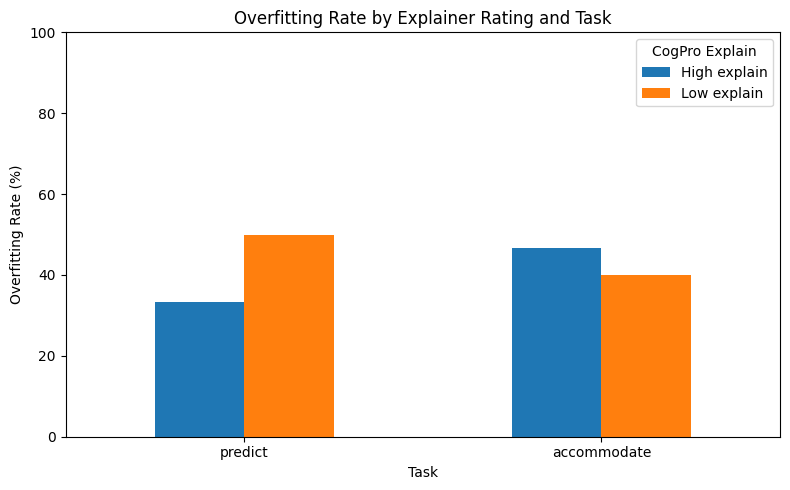

In [39]:
# High/low explainer rating
df_params['explain_group'] = np.where(
    df_params['cogpro_explain'] >= 4,
    'High explain',
    'Low explain'
)

# Overfitting rate by explain group and irrelevant feature
overfit_explain_summary = (
    df_params
    .groupby(['explain_group', 'task'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_explain_summary['overfit_percent'] = overfit_explain_summary['mean'] * 100

print(overfit_explain_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = overfit_explain_summary.pivot(
    index='task',
    columns='explain_group',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Explainer Rating and Task')
ax.set_xlabel('Task')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='CogPro Explain')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'OverfittingRateByCogProExplainandtask.png'), dpi=300)
plt.show()

  predict_group         task      mean  sum  count  overfit_percent
0  High predict      predict  0.444444    8     18        44.444444
1  High predict  accommodate  0.533333    8     15        53.333333
2   Low predict      predict  0.000000    0      2         0.000000
3   Low predict  accommodate  0.000000    0      2         0.000000


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_51179/2237765179.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['predict_group', 'task'])['overfit']


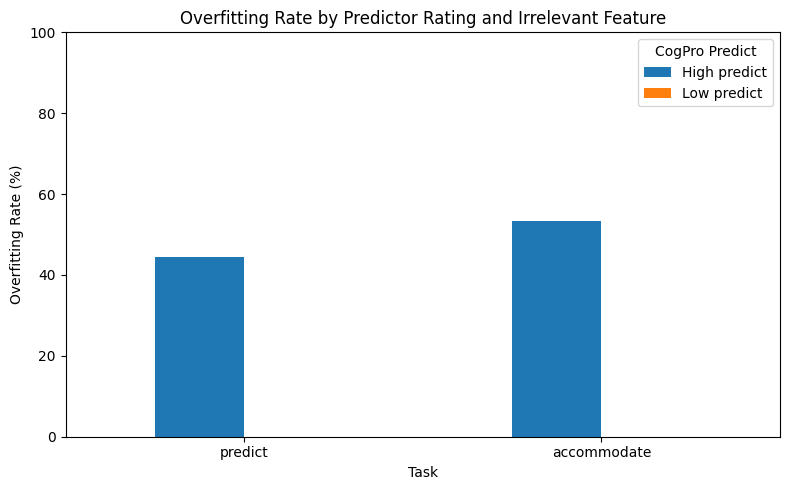

In [14]:
# High/low explainer rating
df_params['predict_group'] = np.where(
    df_params['cogpro_predict'] >= 4,
    'High predict',
    'Low predict'
)

# Overfitting rate by explain group and irrelevant feature
overfit_predict_summary = (
    df_params
    .groupby(['predict_group', 'task'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_predict_summary['overfit_percent'] = overfit_predict_summary['mean'] * 100

print(overfit_predict_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = overfit_predict_summary.pivot(
    index='task',
    columns='predict_group',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Predictor Rating and Irrelevant Feature')
ax.set_xlabel('Task')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='CogPro Predict')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'OverfittingRateByCogProPredictandtask.png'), dpi=300)
plt.show()

Part 2: Testing distribution of all model parameter scores by task

model_param_score time         task irrelevant_dim     0     1      2
0                  mid      predict        stripes  12.0  55.0   80.0
1                  mid      predict           feet  12.0  49.0   85.0
2                  mid  accommodate        stripes  13.0  61.0   73.0
3                  mid  accommodate           feet  18.0  53.0   75.0
4                  end      predict        stripes   9.0  45.0   93.0
5                  end      predict           feet  10.0  40.0   96.0
6                  end  accommodate        stripes  10.0  38.0   99.0
7                  end  accommodate           feet   9.0  36.0  101.0


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6381/3161188306.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['time', 'task', 'irrelevant_dim', 'model_param_score'])
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6381/3161188306.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  score_pivot = score_counts.pivot_table(


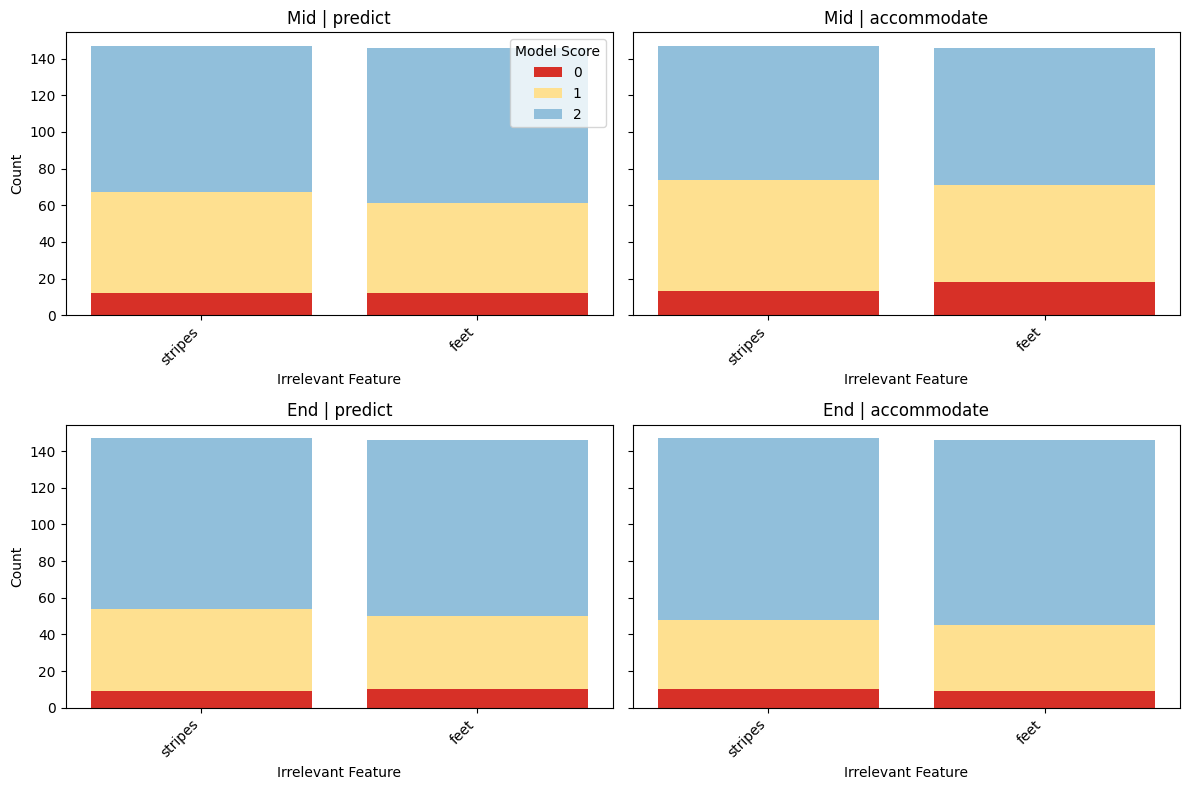

In [52]:
df_params_all['task'] = df_params_all['task'].astype('category')
df_params_all['time'] = pd.Categorical(
    df_params_all['time'],
    categories=['mid', 'end'],
    ordered=True
)

score_counts = (
    df_params_all
    .groupby(['time', 'task', 'irrelevant_dim', 'model_param_score'])
    .size()
    .reset_index(name='count')
)

score_pivot = score_counts.pivot_table(
    index=['time', 'task', 'irrelevant_dim'],
    columns='model_param_score',
    values='count',
    fill_value=0
).reset_index()

print(score_pivot)

tasks = df_params_all['task'].cat.categories
times = ['mid', 'end']
buckets = [0, 1, 2]
colors = ['#d73027', '#fee090', '#91bfdb']

fig, axes = plt.subplots(
    len(times),
    len(tasks),
    figsize=(12, 8),
    sharey=True
)

if len(times) == 1:
    axes = np.array([axes])
if len(tasks) == 1:
    axes = axes.reshape(len(times), 1)

for row_i, time_label in enumerate(times):
    for col_i, task in enumerate(tasks):

        ax = axes[row_i, col_i]

        task_data = score_pivot[
            (score_pivot['time'] == time_label) &
            (score_pivot['task'] == task)
        ].copy()

        x = np.arange(len(task_data))
        bottom = np.zeros(len(task_data))

        for i, b in enumerate(buckets):
            values = (
                task_data[b]
                if b in task_data.columns
                else np.zeros(len(task_data))
            )

            ax.bar(
                x,
                values,
                bottom=bottom,
                label=f"{b}" if row_i == 0 and col_i == 0 else "",
                color=colors[i]
            )

            bottom += values.values if hasattr(values, "values") else values

        ax.set_xticks(x)
        ax.set_xticklabels(task_data['irrelevant_dim'], rotation=45, ha='right')
        ax.set_title(f"{time_label.capitalize()} | {task}")
        ax.set_xlabel("Irrelevant Feature")

        if col_i == 0:
            ax.set_ylabel("Count")

axes[0, 0].legend(title="Model Score")

plt.tight_layout()
# plt.savefig(os.path.join(outputdir, 'Figure3ModelParamScoreDistributionByTaskIrrelevantFeatureAndTime.png'))
plt.show()

model_param_score   0   1    2
task                          
accommodate        18  62  166
predict            15  68  147
Chi-square = 1.167
df = 2
p-value = 0.5581


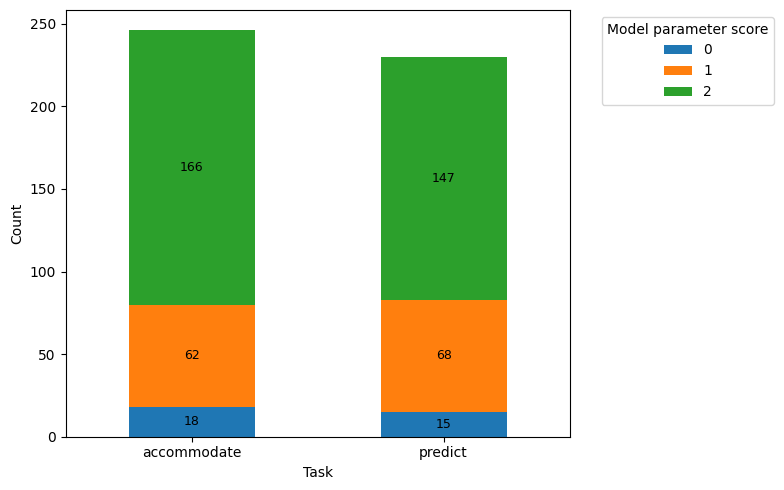

In [14]:
contingency_all = pd.crosstab(
    df_params['task'],
    df_params['model_param_score']
)

print(contingency_all)

chi2, p, dof, expected = chi2_contingency(contingency_all)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

ax = contingency_all.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_xlabel("Task")
ax.set_ylabel("Count")
#ax.set_title("Model Parameter Scores by Task")

# Add numerical labels with the count
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",
        fontsize=9
    )
plt.legend(title="Model parameter score", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "Figure2_TaskByModelParamScore_StackedBars.png"),
    dpi=300
)
plt.show()
plt.close()

#Function of condition, wing relevance, and wing direction - the full distribution across that 
#code explanations later


**Primary Analysis #2: Predicting Feature Importance Ratings**

In [53]:
#Create map from short codes to feature descriptions

feet_map = {
    'webbed': 'f',
    'curved/pointy': 'c'
}

stripes_map = {
    'up/right': 'e',
    'up/left': 'w'
}



feature_maps = {
    'feet': feet_map,
    'stripes': stripes_map
}


In [54]:
#Compute feature importance scores

from doctest import debug


def compute_feature_importance_from_df(df):
    """
    Compute numeric feature importance scores(-7 to 7) for each participant,
    based on the saved slider_responses and the feature _high/_low mapping.
    This is computed based on whether a feature was really relevant (positive sign) or irrelevant (negative sign).
    0 = no response or feature was not thought to be relevant
    columns:
      - wings_discrete_slider.response, wings_direction_slider.response, wings_continuous_slider.response
      - color_discrete_slider.response, ...
      - tail_discrete_slider.response, ...
      - wings_high, wings_low, color_high, color_low, tail_high, tail_low
    """
    features = ['feet', 'stripes']
    def compute_row_importance(row, feat, mid):
        if mid:
            suffix = '_mid'
        else:
            suffix = ''
        disc = row[f'{feat}_discrete_slider{suffix}.response']
        dirc = row[f'{feat}_direction_slider{suffix}.response']
        cont = row[f'{feat}_continuous_slider{suffix}.response']

        #If they said a feature wasn't relevant, then importance is 0
        
        if disc == 'No' or pd.isna(disc):
            return 0.0
        
        # Make sure continuous slider value exists, if not, set it to 0
        cont_val = float(cont) if not pd.isna(cont) else 0.0

        # Get mapping from long to short feature name
        mapping = feature_maps.get(feat, {})

        # Normalize strings: strip whitespace, collapse multiple spaces, lower-case
        def normalize_str(s):
            """Strip leading/trailing whitespace and collapse internal multiple spaces."""

            if isinstance(s, str):
                return " ".join(s.split()).lower()
            return ""
        

        #Name of features need to be normalized for comparison using the mapping
        dirc_norm = normalize_str(dirc)

        #Get internal short code for selected feature direction
        internal_dirc = mapping.get(dirc_norm, None)
        

        high_val = normalize_str(row[f'{feat}_high'])
        low_val  = normalize_str(row[f'{feat}_low'])
        

        
        # Debug print statement (make sure mappings look right)
        debug = True
        if debug:
            print('response:', repr(dirc_norm), 'internal:', repr(internal_dirc), 
                'high:', repr(high_val), 'low:', repr(low_val))
            

        #If they correctly selected the high feature, assign positive sign
        if internal_dirc == high_val:
            sign = 1
        #If they incorrectly selected the low feature, assign negative sign
        elif internal_dirc == low_val:
            if debug:
                print('in negative')
            sign = -1
        else:
            if debug:
                print('in empty')
            sign = 0
            cont_val = 0.0

        # Add sign to continuous value
        importance = cont_val * sign

        return importance

    
    # Compute for each feature
    for feat in features:
        df[f'{feat}_importance'] = df.apply(lambda row: compute_row_importance(row, feat, mid=False), axis=1)
        df[f'{feat}_importance_mid'] = df.apply(lambda row: compute_row_importance(row, feat, mid=True), axis=1)
    
    return df

df_combined = compute_feature_importance_from_df(df_combined)
#df_filtered = compute_feature_importance_from_df(df_filtered)
if debug:
    print(df_combined['feet_importance'])

response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'c' low: 'f'
in negative
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'f' low: 

In [55]:
import pandas as pd
"""Reshape to long format with 1 row per participant x feature dimension"""
# Keep only necessary columns
cols_to_keep = [
    'participant', 'task', 
    'feet_importance', 'feet_importance_mid', 'stripes_importance', 'stripes_importance_mid',
    'relevant_dim', 'irrelevant_dim', 'feet_high','stripes_high', 'feet_discrete_slider.response',
    'cogpro_explain', 'cogpro_predict'
]

df_long = df_combined[cols_to_keep].copy()

df_long = df_long.melt(
    id_vars=[
        'participant', 'task', 'relevant_dim', 'irrelevant_dim',
        'stripes_high', 'feet_high', 'feet_discrete_slider.response',
        'cogpro_explain', 'cogpro_predict'
    ],
    value_vars=[
        'feet_importance', 'feet_importance_mid',
        'stripes_importance', 'stripes_importance_mid'
    ],
    var_name='feature_dimension',
    value_name='feature_importance'
)

# create time column
df_long['time'] = np.where(
    df_long['feature_dimension'].str.endswith('_mid'),
    'mid',
    'end'
)

# clean feature dimension back to feet/stripes
df_long['feature_dimension'] = (
    df_long['feature_dimension']
    .str.replace('_importance_mid', '', regex=False)
    .str.replace('_importance', '', regex=False)
)

df_long['feature_relevance'] = np.where(
    df_long['feature_dimension'] == df_long['relevant_dim'],
    'relevant',
    'irrelevant'
)

print(df_long.tail(20))

      participant     task relevant_dim irrelevant_dim stripes_high feet_high  \
2324          567  predict      stripes           feet            E         F   
2325          568  predict      stripes           feet            W         C   
2326          569  predict         feet        stripes            E         C   
2327          570  predict         feet        stripes            E         F   
2328          571  predict      stripes           feet            E         F   
2329          572  predict      stripes           feet            E         C   
2330          573  predict      stripes           feet            E         C   
2331          574  predict         feet        stripes            E         F   
2332          575  predict         feet        stripes            E         C   
2333          576  predict      stripes           feet            W         C   
2334          577  predict      stripes           feet            W         F   
2335          578  predict  

MID FEET — relevant: 294 points
MID FEET — irrelevant: 292 points
MID STRIPES — relevant: 292 points
MID STRIPES — irrelevant: 294 points
END FEET — relevant: 294 points
END FEET — irrelevant: 292 points
END STRIPES — relevant: 292 points
END STRIPES — irrelevant: 294 points


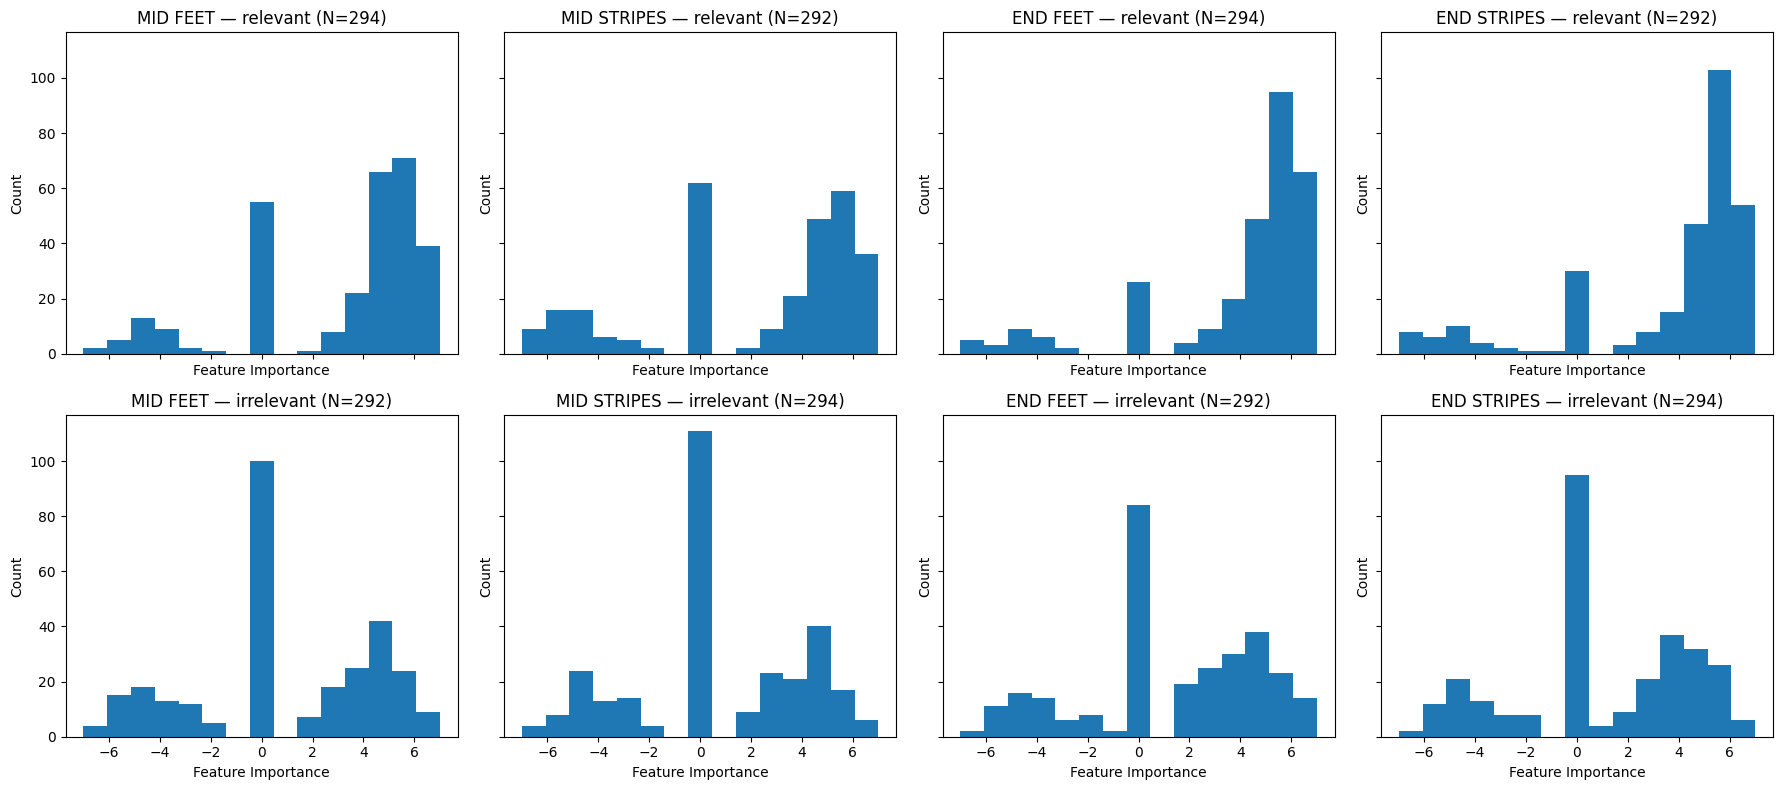

In [56]:
features = ['feet', 'stripes']
times = ['mid', 'end']
relevance_states = ['relevant', 'irrelevant']

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)

for col, (time_label, feat) in enumerate(
    [(t, f) for t in times for f in features]
):
    for row, rel in enumerate(relevance_states):

        ax = axes[row, col]

        subset = df_long[
            (df_long['time'] == time_label) &
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ]

        n_points = len(subset)
        print(f"{time_label.upper()} {feat.upper()} — {rel}: {n_points} points")

        ax.hist(subset['feature_importance'], bins=15, density=False)
        ax.set_title(f"{time_label.upper()} {feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Feature Importance")
        ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6381/2558768501.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6381/2558768501.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


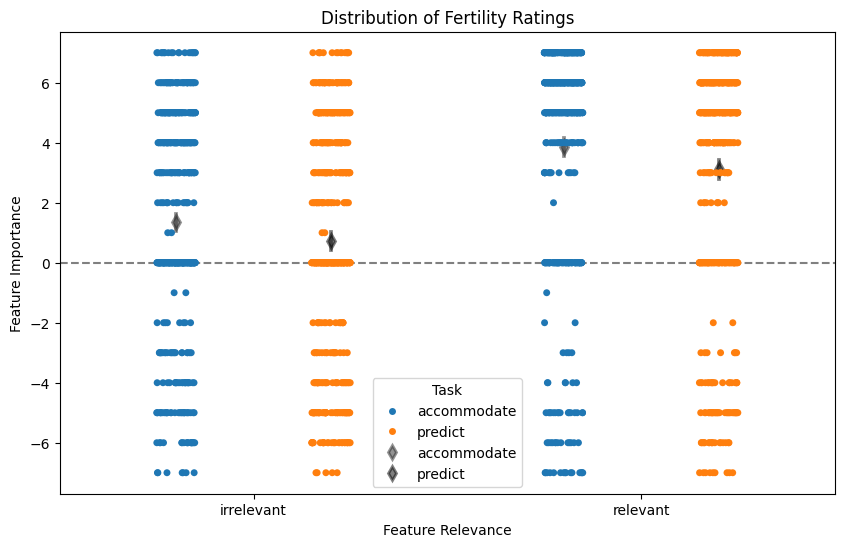

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.stripplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha = .5
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Fertility Ratings')
plt.ylabel('Feature Importance')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)

plt.show()


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6381/3345831810.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6381/3345831810.py:12: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


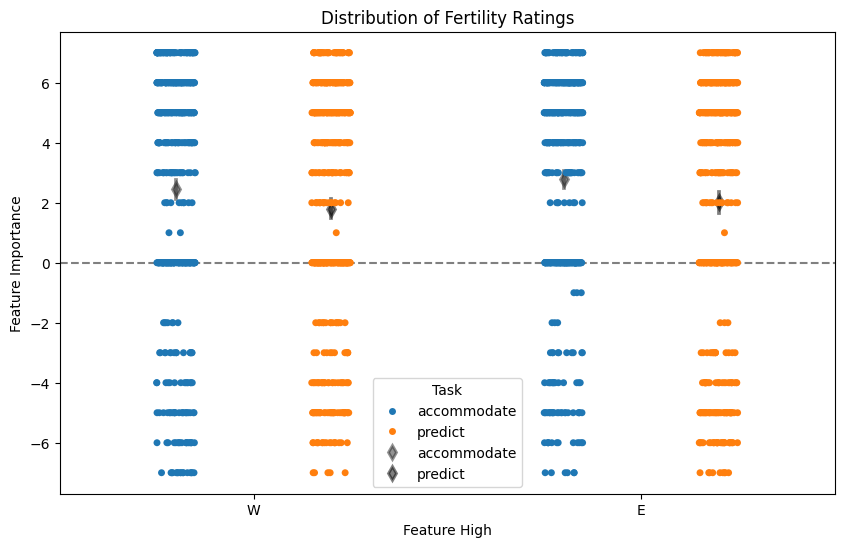

In [58]:

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df_long,
    x='stripes_high',
    y='feature_importance',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='stripes_high',
    y='feature_importance',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha = .5
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Fertility Ratings')
plt.ylabel('Feature Importance')
plt.xlabel('Feature High')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByTaskAndFeetViolin.png'), dpi=300)

plt.show()


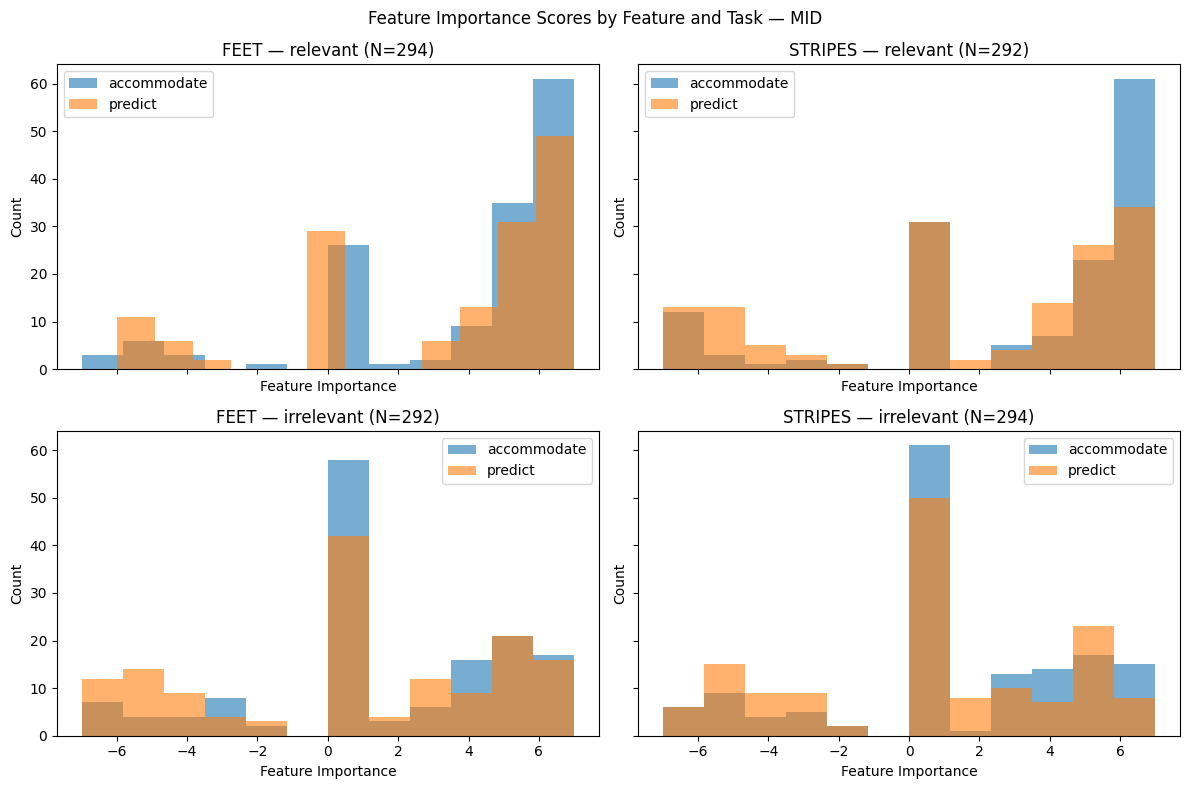

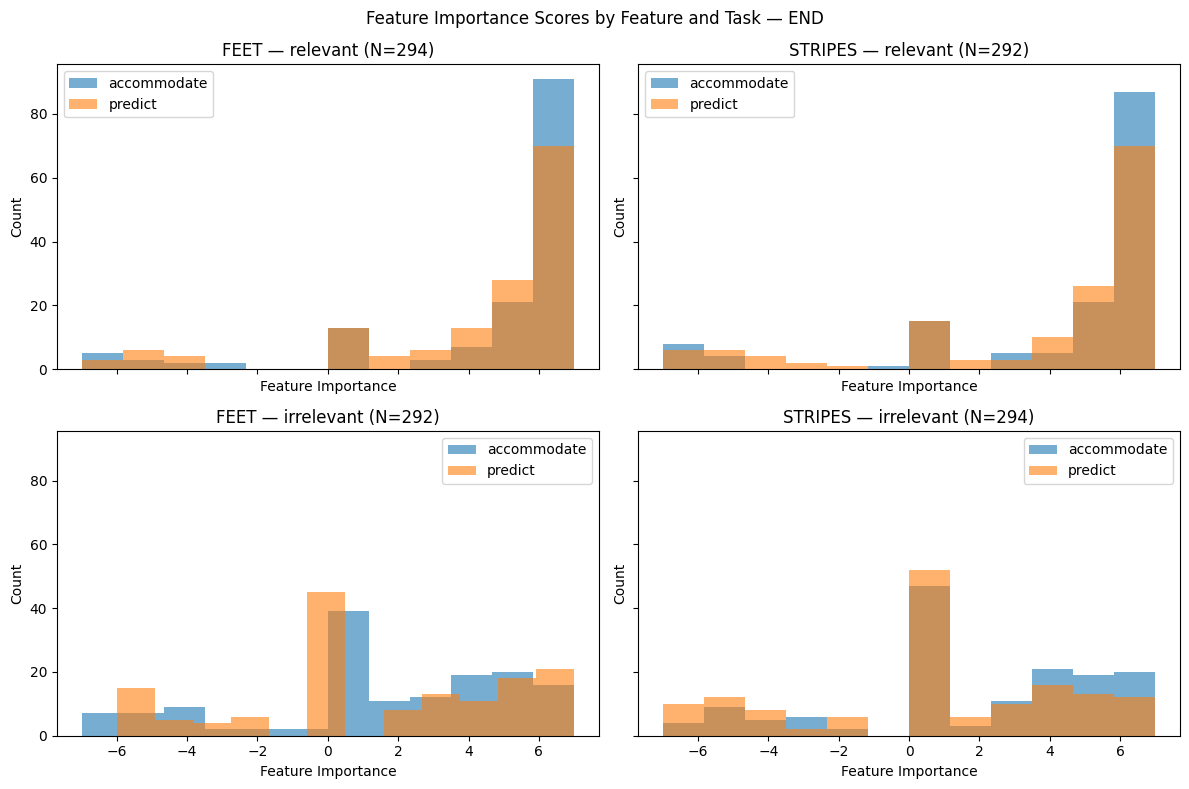

In [59]:
import matplotlib.pyplot as plt

features = ['feet', 'stripes']
relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()
times = ['mid', 'end']

for time_label in times:

    df_time = df_long[df_long['time'] == time_label]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

    for col, feat in enumerate(features):
        for row, rel in enumerate(relevance_states):

            ax = axes[row, col]

            for task in tasks:
                subset = df_time[
                    (df_time['feature_dimension'] == feat) &
                    (df_time['feature_relevance'] == rel) &
                    (df_time['task'] == task)
                ]

                ax.hist(
                    subset['feature_importance'],
                    bins=12,
                    density=False,
                    alpha=0.6,
                    label=task
                )

            n_points = len(df_time[
                (df_time['feature_dimension'] == feat) &
                (df_time['feature_relevance'] == rel)
            ])

            ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
            ax.set_xlabel("Feature Importance")
            ax.set_ylabel("Count")
            ax.legend()

    plt.suptitle(f"Feature Importance Scores by Feature and Task — {time_label.upper()}")
    plt.tight_layout()

    # plt.savefig(os.path.join(outputdir, f'FeatureImportanceScoresbyFeaturesAndTask_{time_label}.png'))

    plt.show()

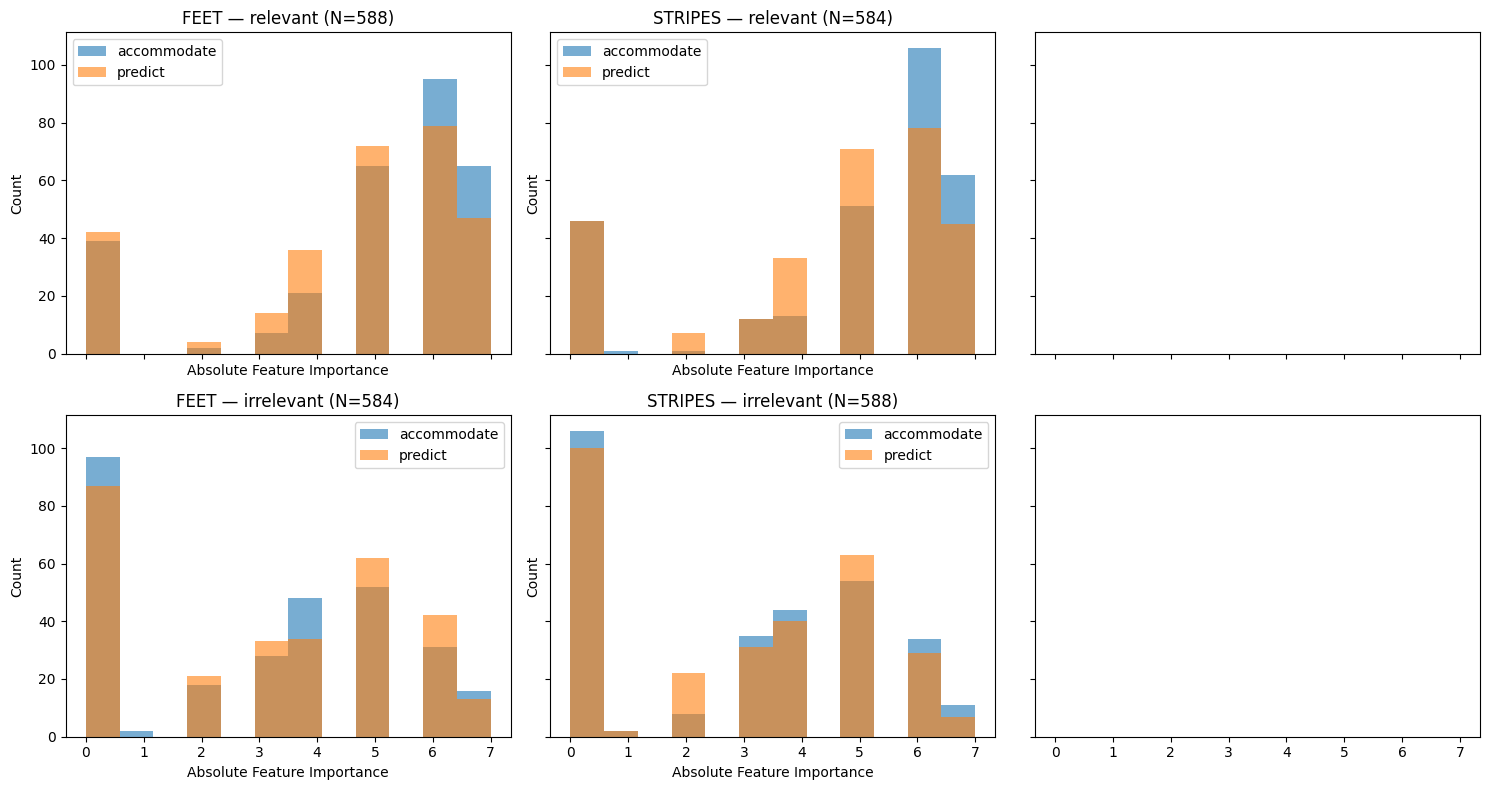

In [60]:
df_long['abs_feature_importance'] = df_long['feature_importance'].abs()
import matplotlib.pyplot as plt
import os

features = ['feet', 'stripes']
relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):

        ax = axes[row, col]

        for task in tasks:
            subset = df_long[
                (df_long['feature_dimension'] == feat) &
                (df_long['feature_relevance'] == rel) &
                (df_long['task'] == task)
            ]

            ax.hist(
                subset['abs_feature_importance'],
                bins=12,
                density=False,
                alpha=0.6,
                label=task
            )

        n_points = len(df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ])

        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Absolute Feature Importance")
        ax.set_ylabel("Count")
        ax.legend()

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'AbsoluteFeatureImportanceScoresbyFeaturesAndTask.png'))
plt.show()

/opt/miniconda3/envs/predictproj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/predictproj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)


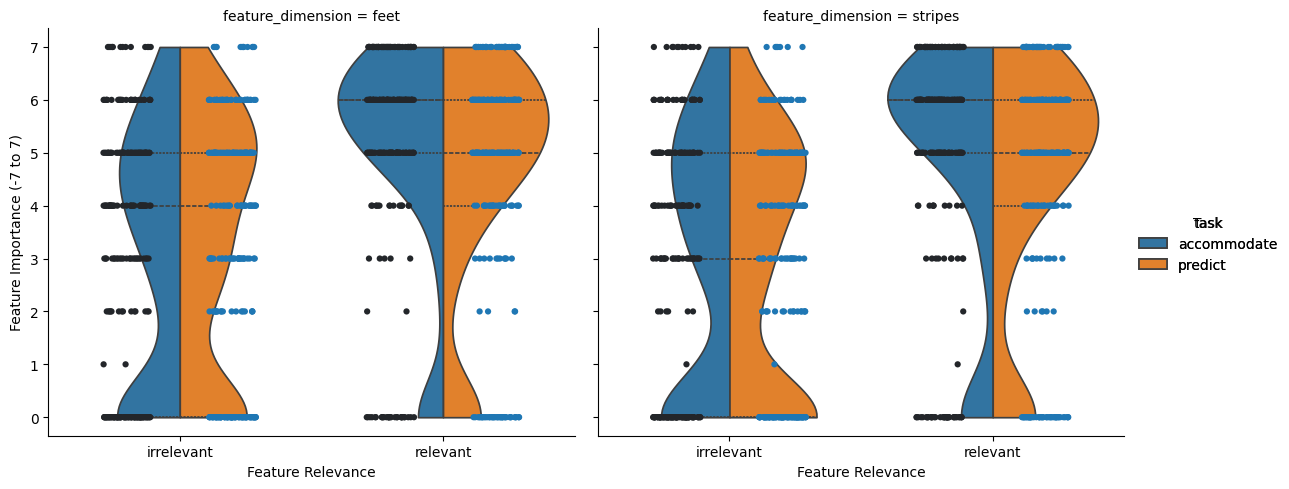

In [17]:
g = sns.catplot(
    data=df_long,
    x='feature_relevance',
    y='abs_feature_importance',
    hue='task',
    col='feature_dimension',
    kind='violin',
    split=True,
    inner='quartile',
    cut=0,
    #density_norm='width',   
    #common_norm=False,     
    height=5,
    aspect=1
)

g.map_dataframe(
    sns.stripplot,
    x='feature_relevance',
    y='abs_feature_importance',
    hue='task',
    dodge=True,
    alpha=1,
    size=4.5,
    jitter=0.18,
    legend=False
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.add_legend(title='Task')

plt.show()

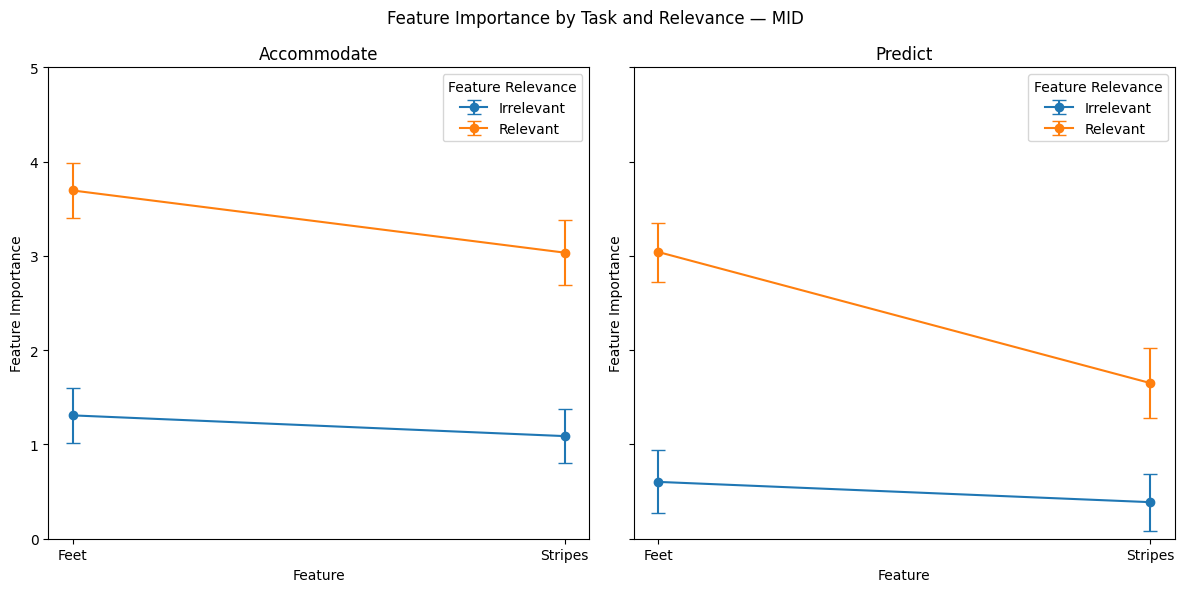

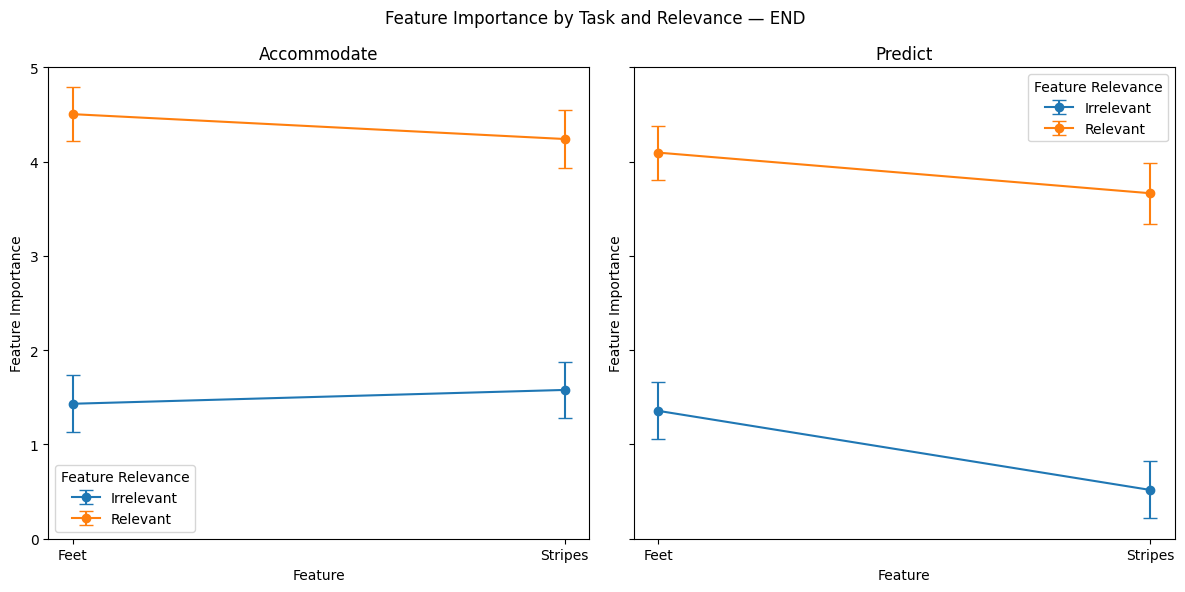

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import os

features = ['feet', 'stripes']
times = ['mid', 'end']


for time_label in times:

    df_time = df_long[df_long['time'] == time_label]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    for i, task in enumerate(df_time["task"].unique()):
        ax = axes[i]

        task_df = df_time[df_time["task"] == task]

        for rel in ['irrelevant', 'relevant']:
            rel_df = task_df[task_df["feature_relevance"] == rel]

            means = []
            ses = []

            for feat in features:
                cell = rel_df[rel_df["feature_dimension"] == feat]["feature_importance"]

                means.append(cell.mean())
                ses.append(cell.std(ddof=1) / np.sqrt(len(cell)) if len(cell) > 1 else 0)

            ax.errorbar(
                range(len(features)),
                means,
                yerr=ses,
                marker='o',
                capsize=5,
                label=rel.capitalize()
            )

        ax.set_title(task.capitalize())
        ax.set_ylim(0, 5)
        ax.set_xticks(range(len(features)))
        ax.set_xticklabels([f.capitalize() for f in features])
        ax.set_xlabel("Feature")
        ax.set_ylabel("Feature Importance")
        ax.legend(title="Feature Relevance")

    plt.suptitle(f"Feature Importance by Task and Relevance — {time_label.upper()}")
    plt.tight_layout()

    # plt.savefig(os.path.join(outputdir, f'Figure5FeatureImportanceByTaskAndRelevance_{time_label}.png'))

    plt.show()

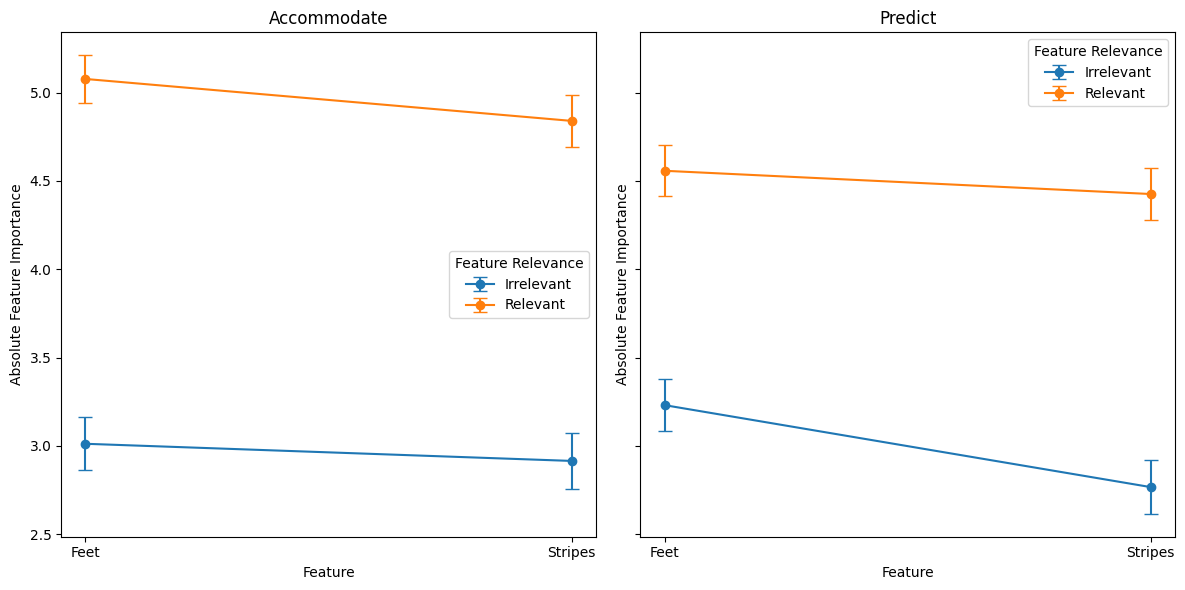

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import os

features = ['feet', 'stripes']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for i, task in enumerate(df_long["task"].unique()):
    ax = axes[i]
    
    task_df = df_long[df_long["task"] == task]

    for rel in ['irrelevant', 'relevant']:
        rel_df = task_df[task_df["feature_relevance"] == rel]
        
        means = []
        ses = []

        for feat in features:
            cell = rel_df[rel_df["feature_dimension"] == feat]["abs_feature_importance"]
            
            means.append(cell.mean())
            ses.append(cell.std(ddof=1) / np.sqrt(len(cell)) if len(cell) > 1 else 0)

        label = rel.capitalize()
        ax.errorbar(
            range(len(features)),
            means,
            yerr=ses,
            marker='o',
            capsize=5,
            label=label
        )

    ax.set_title(task.capitalize())
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels([f.capitalize() for f in features])
    ax.set_xlabel("Feature")
    ax.set_ylabel("Absolute Feature Importance")
    ax.legend(title="Feature Relevance")

plt.tight_layout()
plt.show()

In [62]:
print(df_long)
df_long.to_csv(os.path.join(outputdirCombined, 'df_long_for_R-Study5.csv'), index=False)

      participant         task relevant_dim irrelevant_dim stripes_high  \
0               1  accommodate      stripes           feet            W   
1               2  accommodate      stripes           feet            W   
2               3  accommodate         feet        stripes            W   
3               4  accommodate         feet        stripes            W   
4               5  accommodate         feet        stripes            E   
...           ...          ...          ...            ...          ...   
2339          582      predict         feet        stripes            W   
2340          583      predict      stripes           feet            W   
2341          584      predict         feet        stripes            W   
2342          585      predict         feet        stripes            E   
2343          586      predict      stripes           feet            W   

     feet_high feet_discrete_slider.response  cogpro_explain  cogpro_predict  \
0            C     

In [20]:
means = (
    df_long
    .groupby(["task", "feature_relevance", "feature_dimension"])["feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


          task feature_relevance feature_dimension      mean       std  count
0  accommodate        irrelevant              feet  1.519531  3.542405    256
1  accommodate        irrelevant           stripes  1.231707  3.609394    246
2  accommodate          relevant              feet  4.142276  3.617430    246
3  accommodate          relevant           stripes  3.636719  3.966138    256
4      predict        irrelevant              feet  1.019531  3.882036    256
5      predict        irrelevant           stripes  0.479508  3.608915    244
6      predict          relevant              feet  3.532787  3.664274    244
7      predict          relevant           stripes  2.582031  4.292391    256


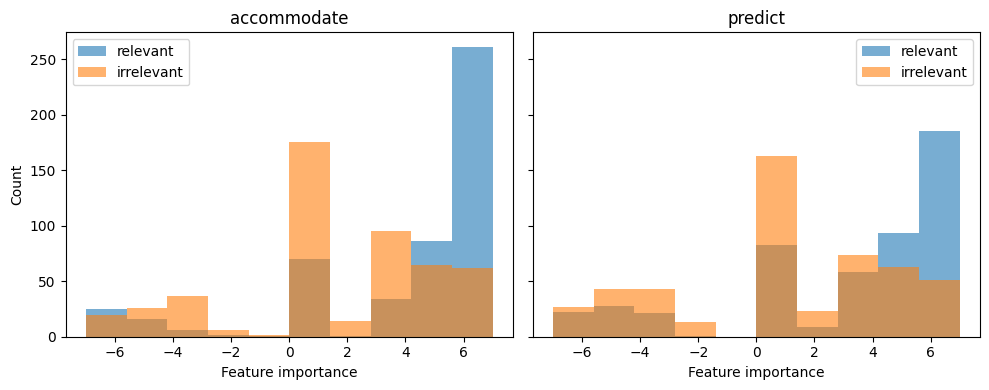

In [21]:
tasks = df_long['task'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(tasks),
    figsize=(5 * len(tasks), 4),
    sharey=True
)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    for label in ['relevant', 'irrelevant']:
        values = df_long.loc[
            (df_long['task'] == task) &
            (df_long['feature_relevance'] == label),
            'feature_importance'
        ]
        ax.hist(values, bins=10, alpha=0.6, label=label)

    ax.set_title(task)
    ax.set_xlabel("Feature importance")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure3_FeatureImportanceByTaskAndRelevance.png'), dpi=300)
plt.show()


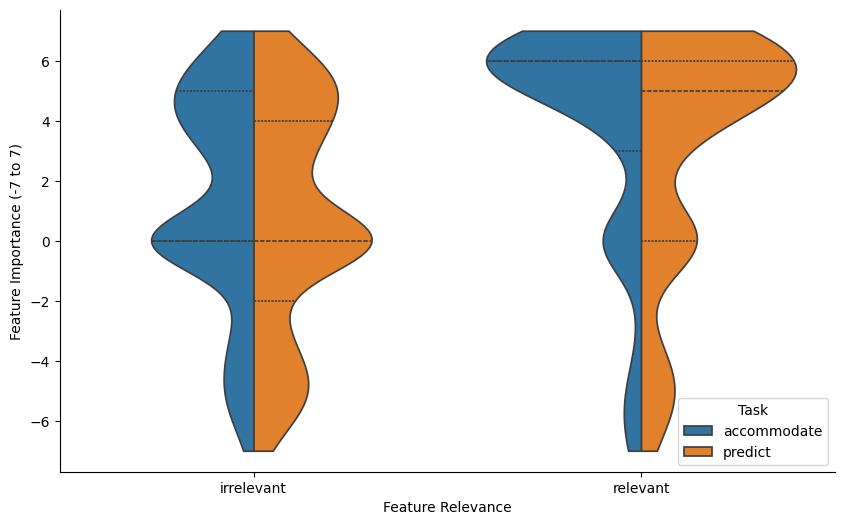

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)
# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

sns.despine()
#plt.axhline(0, color='gray', linestyle='--')  # line at 0
#plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task', loc='lower right')
#plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()


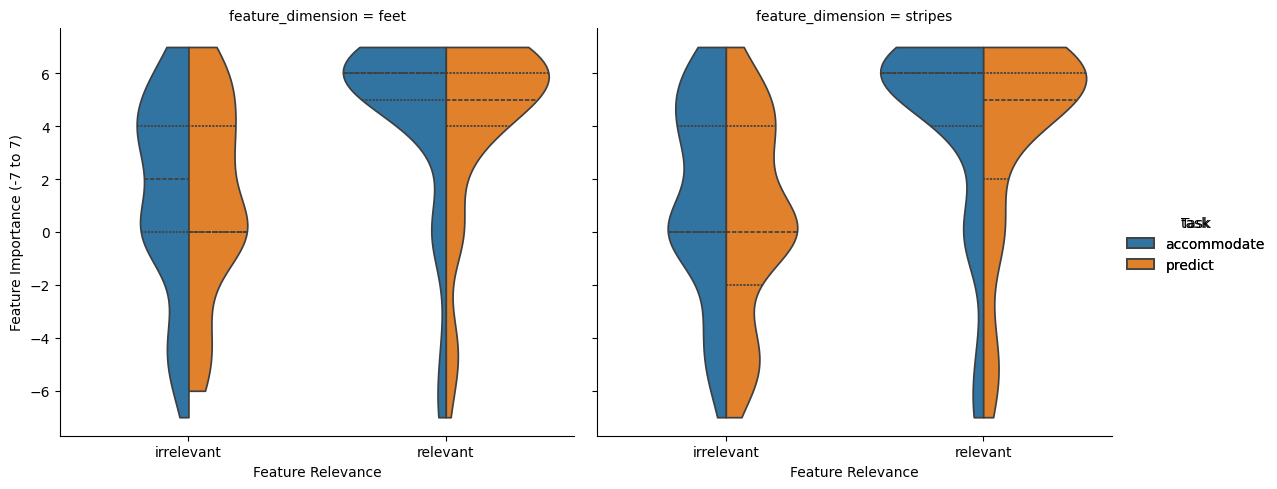

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

df_long['feature_relevance'] = pd.Categorical(
    df_long['feature_relevance'],
    categories=['irrelevant', 'relevant'],
    ordered=False
)

g = sns.catplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    col='feature_dimension',     
    kind='violin',
    split=True,
    inner='quartile',
    cut=0,
    height=5,
    aspect=1
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.add_legend(title='Task')

sns.despine()

'''
plt.savefig(
    os.path.join(outputdir, 'Figure4_FeatureImportance_ByTask_Relevance_FacetedByDimension.png'),
    dpi=300
)
'''
plt.show()

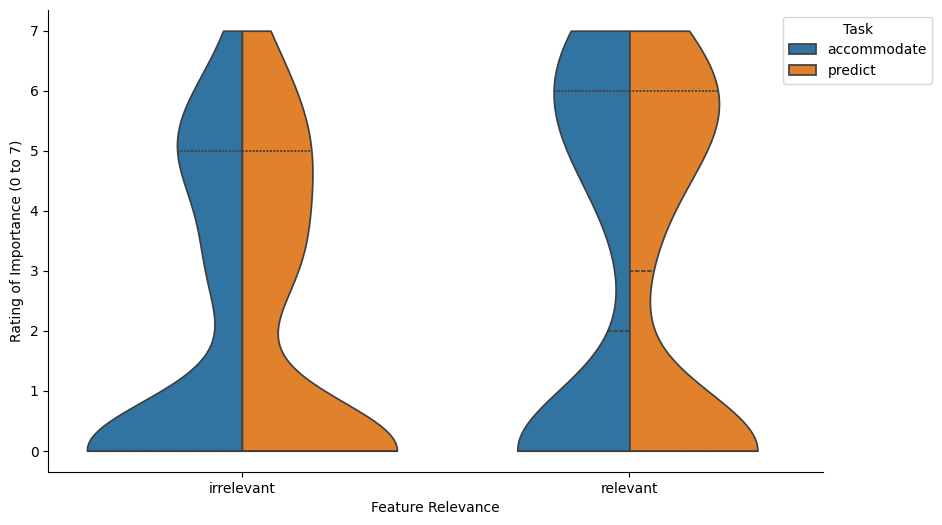

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)
# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='abs_feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

sns.despine()
#plt.axhline(0, color='gray', linestyle='--')  # line at 0
#plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Rating of Importance (0 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task', loc ='upper right', bbox_to_anchor=(1.15, 1))
#plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()


**Analysis 3: Predicting Fertility Ratings**

In [110]:
#Group by average food amount per item in training
df = df_combined[['task', 'feet_high', 'stripes_high', 'training_image_order', 'fertility_score', 'conditionOrder']]
df_long2 = (
    df
    .explode(['training_image_order', 'fertility_score'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food = (
    df_long2
    .groupby(['task', 'conditionOrder', 'item'], as_index=False)
    ['fertility_score']
    .mean()
)
avg_food_train = avg_food.copy()
print(avg_food_train.head(20))

avg_food_2 = (
    df_long2
    .groupby(['task', 'conditionOrder', 'item', 'feet_high', 'stripes_high'], as_index=False)
    ['fertility_score']
    .mean()
)
print(avg_food_2.head(20))


           task  conditionOrder item fertility_score
0   accommodate               1  E_C             7.5
1   accommodate               1  E_F             4.5
2   accommodate               1  W_C             6.0
3   accommodate               1  W_F             2.5
4   accommodate               2  E_C            2.25
5   accommodate               2  E_F             2.5
6   accommodate               2  W_C            8.25
7   accommodate               2  W_F            6.25
8   accommodate               3  E_C            3.75
9   accommodate               3  E_F             7.5
10  accommodate               3  W_C            4.75
11  accommodate               3  W_F            8.25
12  accommodate               4  E_C            6.75
13  accommodate               4  E_F             8.0
14  accommodate               4  W_C             4.5
15  accommodate               4  W_F             4.5
16  accommodate               5  E_C             6.5
17  accommodate               5  E_F          

In [82]:
#Get food consumption ratings by item

df = df_combined[['task', 'conditionOrder', 'testing_image_order', 'testing_responses',
                  'relevant_dim', 'irrelevant_dim', 'stripes_high', 'feet_high']]
df_long2 = (
    df
    .explode(['testing_image_order', 'testing_responses'])
    .rename(columns={'testing_image_order': 'item'})
)
avg_food_test = df_long2.copy()
print(avg_food_test)


            task  conditionOrder item testing_responses relevant_dim  \
0    accommodate             226  W_F               6.0      stripes   
0    accommodate             226  W_C               6.0      stripes   
0    accommodate             226  E_F               6.0      stripes   
0    accommodate             226  E_C               6.0      stripes   
1    accommodate             210  W_C               9.0      stripes   
..           ...             ...  ...               ...          ...   
584      predict             265  W_F               1.0         feet   
585      predict              86  W_F               9.0      stripes   
585      predict              86  E_F               2.0      stripes   
585      predict              86  W_C               8.0      stripes   
585      predict              86  E_C               3.0      stripes   

    irrelevant_dim stripes_high feet_high  
0             feet            W         C  
0             feet            W         C  
0  

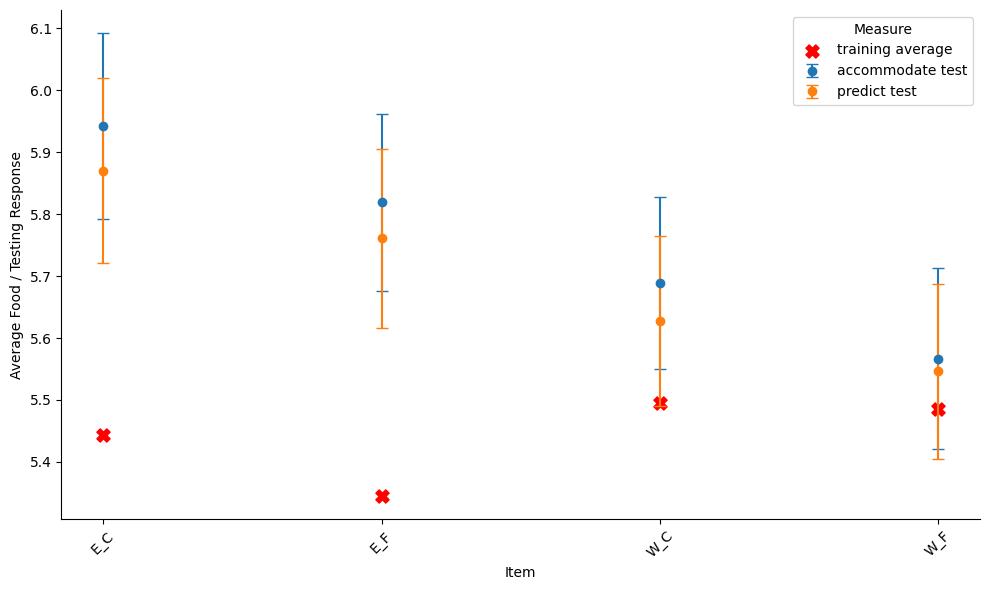

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Test means + SE by task/item
summary = (
    avg_food_test
    .groupby(['task', 'item'])['testing_responses']
    .agg(['mean', 'sem'])
    .reset_index()
)

# Training overall average by task/item
train_summary = (
    avg_food_train
    .groupby(['task', 'item'])['fertility_score']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

items = summary['item'].drop_duplicates().tolist()
x = np.arange(len(items))

for task in summary['task'].unique():
    df_task = (
        summary[summary['task'] == task]
        .set_index('item')
        .reindex(items)
        .reset_index()
    )

    train_task = (
        train_summary[train_summary['task'] == task]
        .set_index('item')
        .reindex(items)
        .reset_index()
    )
    plt.errorbar(
        x,
        df_task['mean'],
        yerr=df_task['sem'],
        fmt='o',
        capsize=4,
        label=f'{task} test'
    )


plt.scatter(
    x,
    train_task['fertility_score'],
    marker='X',
    color='red',
    s=90,
    label=f'training average'
)
plt.xticks(x, items, rotation=45)
plt.xlabel("Item")
plt.ylabel("Average Food / Testing Response")
plt.legend(title="Measure")
sns.despine()
plt.tight_layout()
plt.show()

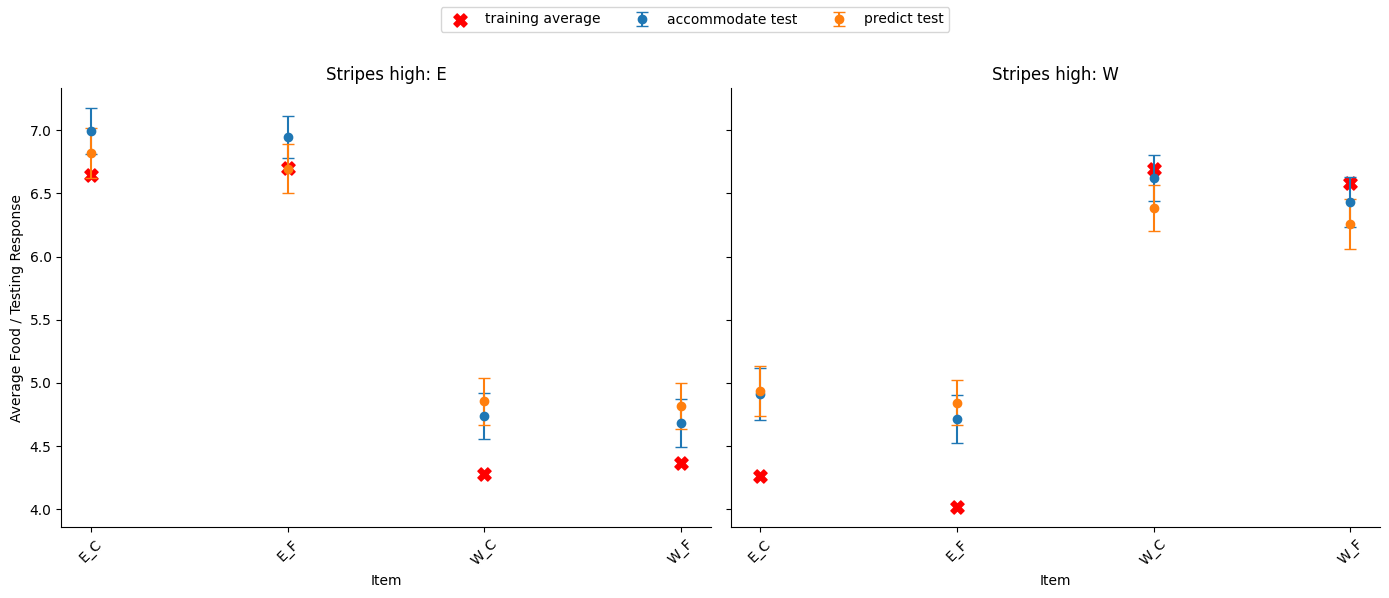

In [115]:
# Test means + SE by stripes_high/task/item
summary = (
    avg_food_test
    .groupby(['stripes_high', 'task', 'item'])['testing_responses']
    .agg(['mean', 'sem'])
    .reset_index()
)

# Training average by stripes_high/item
train_summary = (
    avg_food_2
    .groupby(['stripes_high', 'item'])['fertility_score']
    .mean()
    .reset_index()
)

stripe_levels = summary['stripes_high'].unique()

fig, axes = plt.subplots(
    1,
    len(stripe_levels),
    figsize=(7 * len(stripe_levels), 6),
    sharey=True
)

if len(stripe_levels) == 1:
    axes = [axes]

for ax, stripes in zip(axes, stripe_levels):

    summary_rel = summary[summary['stripes_high'] == stripes]

    items = summary_rel['item'].drop_duplicates().tolist()
    x = np.arange(len(items))

    for task in summary_rel['task'].unique():
        df_task = (
            summary_rel[summary_rel['task'] == task]
            .set_index('item')
            .reindex(items)
            .reset_index()
        )

        ax.errorbar(
            x,
            df_task['mean'],
            yerr=df_task['sem'],
            fmt='o',
            capsize=4,
            label=f'{task} test'
        )

    train_plot = (
        train_summary[train_summary['stripes_high'] == stripes]
        .set_index('item')
        .reindex(items)
        .reset_index()
    )

    ax.scatter(
        x,
        train_plot['fertility_score'],
        marker='X',
        color='red',
        s=90,
        label='training average'
    )

    ax.set_title(f"Stripes high: {stripes}")
    ax.set_xticks(x)
    ax.set_xticklabels(items, rotation=45)
    ax.set_xlabel("Item")

axes[0].set_ylabel("Average Food / Testing Response")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

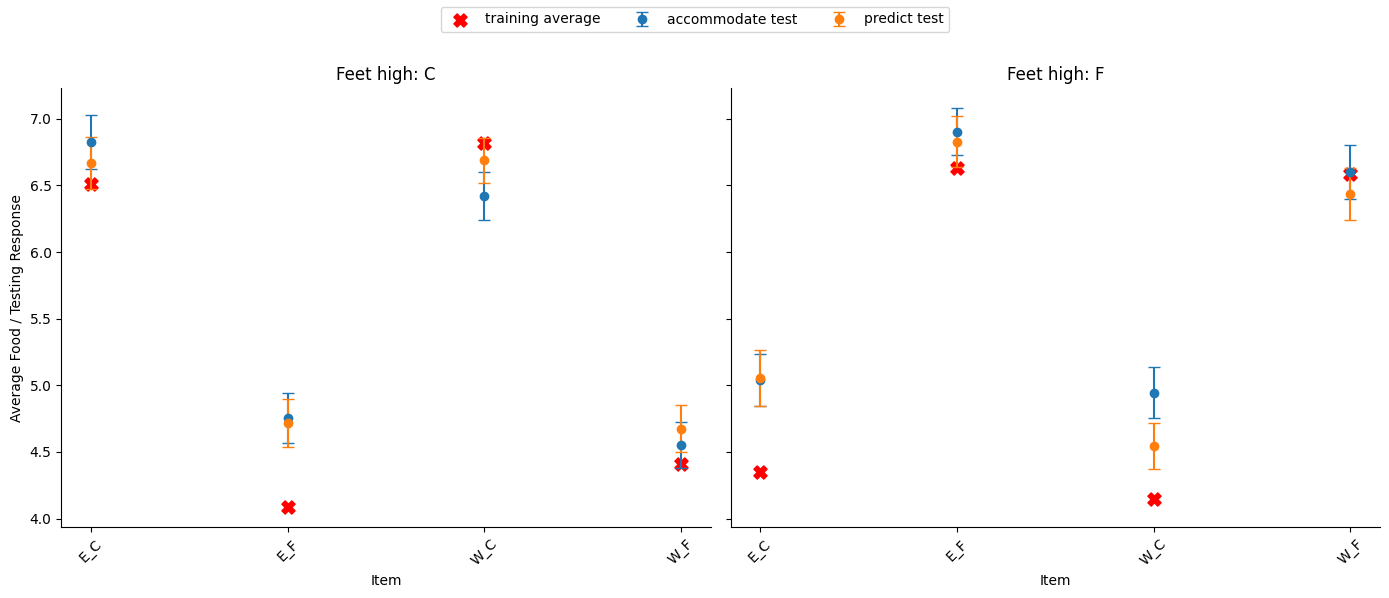

In [114]:
# Test means + SE by stripes_high/task/item
summary = (
    avg_food_test
    .groupby(['feet_high', 'task', 'item'])['testing_responses']
    .agg(['mean', 'sem'])
    .reset_index()
)

# Training average by stripes_high/item
train_summary = (
    avg_food_2
    .groupby(['feet_high', 'item'])['fertility_score']
    .mean()
    .reset_index()
)

stripe_levels = summary['feet_high'].unique()

fig, axes = plt.subplots(
    1,
    len(stripe_levels),
    figsize=(7 * len(stripe_levels), 6),
    sharey=True
)

if len(stripe_levels) == 1:
    axes = [axes]

for ax, feet in zip(axes, stripe_levels):

    summary_rel = summary[summary['feet_high'] == feet]

    items = summary_rel['item'].drop_duplicates().tolist()
    x = np.arange(len(items))

    for task in summary_rel['task'].unique():
        df_task = (
            summary_rel[summary_rel['task'] == task]
            .set_index('item')
            .reindex(items)
            .reset_index()
        )

        ax.errorbar(
            x,
            df_task['mean'],
            yerr=df_task['sem'],
            fmt='o',
            capsize=4,
            label=f'{task} test'
        )

    train_plot = (
        train_summary[train_summary['feet_high'] == feet]
        .set_index('item')
        .reindex(items)
        .reset_index()
    )

    ax.scatter(
        x,
        train_plot['fertility_score'],
        marker='X',
        color='red',
        s=90,
        label='training average'
    )

    ax.set_title(f"Feet high: {feet}")
    ax.set_xticks(x)
    ax.set_xticklabels(items, rotation=45)
    ax.set_xlabel("Item")

axes[0].set_ylabel("Average Food / Testing Response")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [83]:
#Now merge the two (actual food amounts in training vs ratings in testing) and compute error
df_merged = avg_food_test.merge(
    avg_food_train,
    on=['task', 'conditionOrder', 'item'],
    how='left'
)

#Add Error and absolute error
df_merged['error'] = (
    df_merged['testing_responses'] - df_merged['fertility_score']
)
df_merged['abs_error'] = df_merged['error'].abs()
df_merged[['stripes', 'feet']] = df_merged['item'].str.split('_', expand=True)

print(df_merged)

             task  conditionOrder item testing_responses relevant_dim  \
0     accommodate             226  W_F               6.0      stripes   
1     accommodate             226  W_C               6.0      stripes   
2     accommodate             226  E_F               6.0      stripes   
3     accommodate             226  E_C               6.0      stripes   
4     accommodate             210  W_C               9.0      stripes   
...           ...             ...  ...               ...          ...   
2339      predict             265  W_F               1.0         feet   
2340      predict              86  W_F               9.0      stripes   
2341      predict              86  E_F               2.0      stripes   
2342      predict              86  W_C               8.0      stripes   
2343      predict              86  E_C               3.0      stripes   

     irrelevant_dim stripes_high feet_high fertility_score error abs_error  \
0              feet            W         C   

In [84]:
#Sanity Check: Mean absolute error by feature (shouldn't be very different)

df_merged[['stripes', 'feet']] = df_merged['item'].str.split('_', expand=True)
print("Mean error by stripes:")
print(df_merged.groupby('stripes')['error'].mean())

print("Mean error by feet:")
print(df_merged.groupby('feet')['error'].mean())
#t-test: stripes 1 vs stripes 2 absolute error 
stripes1 = df_merged.loc[df_merged['feet'] == 'C', 'error']
stripes2 = df_merged.loc[df_merged['feet'] == 'F', 'error']
t_stat, p_val = stats.ttest_ind(pd.to_numeric(stripes1), pd.to_numeric(stripes2), equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")


Mean error by stripes:
stripes
E    0.454352
W    0.116894
Name: error, dtype: object
Mean error by feet:
feet
C     0.31314
F    0.258106
Name: error, dtype: object
T = 0.684, p = 0.494


F
C


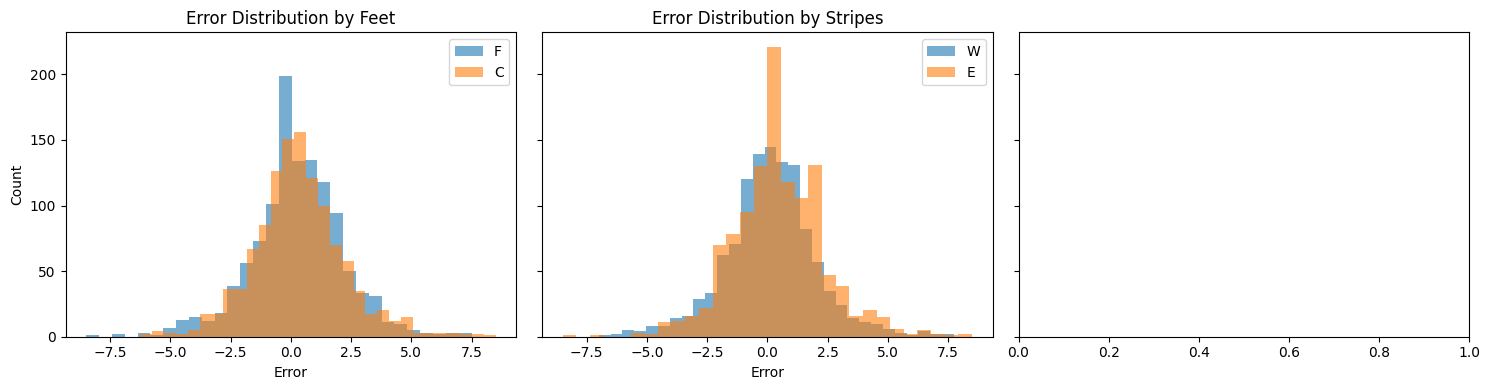

In [85]:
import matplotlib.pyplot as plt

# Make sure error is numeric
df_merged['error'] = pd.to_numeric(df_merged['error'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Tail
for t in df_merged['feet'].unique():
    print(t)
    axes[0].hist(
        df_merged.loc[df_merged['feet'] == t, 'error'],
        bins=30,
        alpha=0.6,
        label=t
    )
axes[0].set_title('Error Distribution by Feet')
axes[0].set_xlabel('Error')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Color ---
for c in df_merged['stripes'].unique():
    axes[1].hist(
        df_merged.loc[df_merged['stripes'] == c, 'error'],
        bins=30,
        alpha=0.6,
        label=c
    )
axes[1].set_title('Error Distribution by Stripes')
axes[1].set_xlabel('Error')
axes[1].legend()

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure7_ErrorDistributionByFeature.png'), dpi=300)
plt.show()


In [86]:
df_merged.to_csv(os.path.join(outputdirCombined, 'df_merged_for_R_Study5.csv'), index=False)

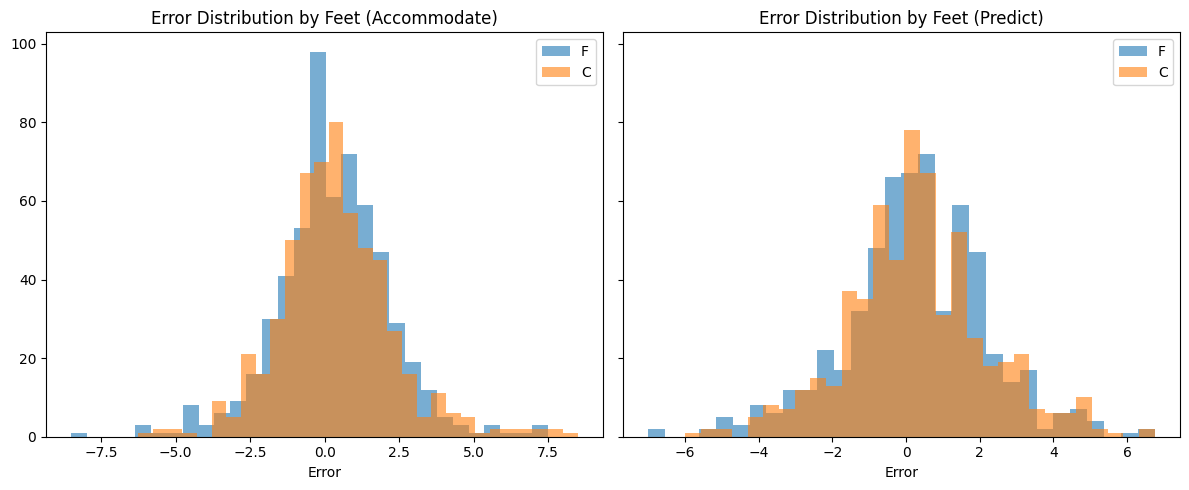

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, task in enumerate(['accommodate', 'predict']):
    for w in df_merged['feet'].unique():
        axes[i].hist(
            df_merged.loc[(df_merged['feet'] == w) & (df_merged['task'] == task), 'error'],
            bins=30,
            alpha=0.6,
            label=w
        )
    axes[i].set_title(f'Error Distribution by Feet ({task.capitalize()})')
    axes[i].set_xlabel('Error')
    axes[i].legend()

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure7b_ErrorDistributionByFeetAndTask.png'), dpi=300)
plt.show()

In [70]:
#Sanity Check: Mean absolute error by feature (shouldn't be very different)

df_merged[['color', 'feet']] = df_merged['item'].str.split('_', expand=True)

print("Mean abs_error by color:")
print(df_merged.groupby('color')['abs_error'].mean())

print("Mean abs_error by feet:")
print(df_merged.groupby('feet')['abs_error'].mean())
#t-test: color 1 vs color 2 absolute error 
color1 = df_merged.loc[df_merged['feet'] == 'C', 'abs_error']
color2 = df_merged.loc[df_merged['feet'] == 'F', 'abs_error']
t_stat, p_val = stats.ttest_ind(pd.to_numeric(color1), pd.to_numeric(color2), equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")


Mean abs_error by color:
color
E    1.491894
W    1.448379
Name: abs_error, dtype: object
Mean abs_error by feet:
feet
C    1.455205
F    1.485068
Name: abs_error, dtype: object
T = -0.553, p = 0.580


In [71]:
#t-test: predict vs accomodate absolute error
df_merged['error'] = pd.to_numeric(df_merged['abs_error'])
print(df_merged.groupby('task')['error'].mean())
errors_task1 = df_merged.loc[df_merged['task'] == 'accommodate', 'error']
errors_task2 = df_merged.loc[df_merged['task'] == 'predict', 'error']
from scipy import stats
t_stat, p_val = stats.ttest_ind(errors_task1, errors_task2, equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_error": [errors_task1.mean(), errors_task2.mean()],
    "t_stat": [t_stat, t_stat], 
    "p_value": [p_val, p_val]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_error.csv"))

task
accommodate    1.465657
predict        1.474616
Name: error, dtype: float64
T = -0.166, p = 0.868


In [72]:
#t-test: predict vs accomodate absolute error
df_merged['abs_error'] = pd.to_numeric(df_merged['abs_error'])
print(df_merged.groupby('task')['abs_error'].mean())
errors_task1 = df_merged.loc[df_merged['task'] == 'accommodate', 'abs_error']
errors_task2 = df_merged.loc[df_merged['task'] == 'predict', 'abs_error']
from scipy import stats
t_stat, p_val = stats.ttest_ind(errors_task1, errors_task2, equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_error": [errors_task1.mean(), errors_task2.mean()],
    "t_stat": [t_stat, t_stat], 
    "p_value": [p_val, p_val]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_error.csv"))

task
accommodate    1.465657
predict        1.474616
Name: abs_error, dtype: float64
T = -0.166, p = 0.868


Part 2: Correlations

In [73]:
# Columns indicating whether the item's feature is the "high" dimension (1 or 0 coding)
df_merged['stripes_match_high']  = (df_merged['stripes']  == df_merged['stripes_high']).astype(int)
df_merged['feet_match_high'] = (df_merged['feet'] == df_merged['feet_high']).astype(int)
#print(df_merged.head(20))
# Group by participant
participant_corrs = []

for pid, g in df_merged.groupby(['task', 'conditionOrder']):
    for feat in ['stripes','feet']:
        # Column indicating match to high value
        match_col = f"{feat}_match_high"
        
        # Compute correlation
        corr = g['testing_responses'].corr(g[match_col])
        
        # Determine if this feature is relevant for this participant
        relevant = g['relevant_dim'].iloc[0] == feat
        high_col  = f"{feat}_high"
        
        # Store
        participant_corrs.append({
            'participant': pid,
            'task': g['task'].iloc[0],
            'feature_dimension': feat,
            'high_value': g[high_col].iloc[0],
            'feature_relevance': 'relevant' if relevant else 'irrelevant',
            'correlation': corr,
            'irrelevant_dim': g['irrelevant_dim'].iloc[0],
            'abs_correlation': abs(corr) if pd.notna(corr) else None
        })

df_corr = pd.DataFrame(participant_corrs)
print(df_corr.tail(40))



         participant     task feature_dimension high_value feature_relevance  \
1132  (predict, 280)  predict           stripes          E          relevant   
1133  (predict, 280)  predict              feet          F        irrelevant   
1134  (predict, 281)  predict           stripes          E        irrelevant   
1135  (predict, 281)  predict              feet          C          relevant   
1136  (predict, 282)  predict           stripes          W          relevant   
1137  (predict, 282)  predict              feet          F        irrelevant   
1138  (predict, 283)  predict           stripes          W        irrelevant   
1139  (predict, 283)  predict              feet          F          relevant   
1140  (predict, 285)  predict           stripes          E        irrelevant   
1141  (predict, 285)  predict              feet          C          relevant   
1142  (predict, 286)  predict           stripes          W          relevant   
1143  (predict, 286)  predict           

/opt/miniconda3/envs/predictproj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/predictproj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [74]:
df_corr.to_csv(os.path.join(outputdirCombined, 'df_corr_for_R_Study5.csv'), index=False)

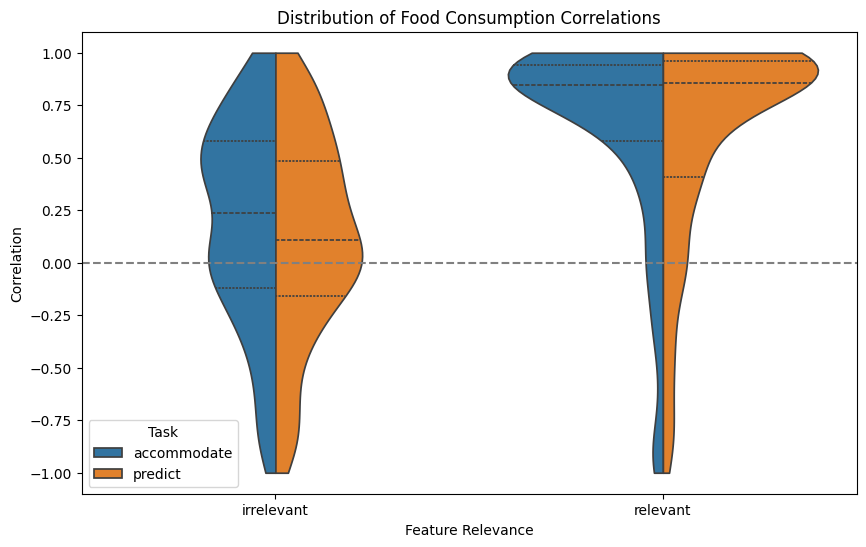

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_corr,
    x='feature_relevance',      # relevant / irrelevant
    y='correlation',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0,

)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Food Consumption Correlations')
plt.ylabel('Correlation')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
#plt.savefig(os.path.join(outputdir, 'Figure10_FeatureCorrelationeByTaskAndRelevanceViolin.png'), dpi=300)

plt.show()


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6381/1081484003.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6381/1081484003.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


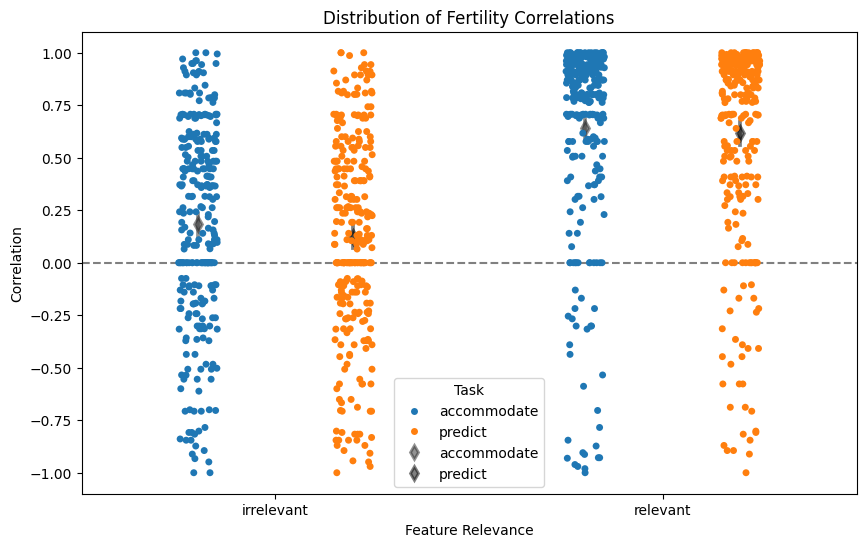

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.stripplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha = .5
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Fertility Correlations')
plt.ylabel('Correlation')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'Figure10_FeatureCorrelationeByTaskAndRelevanceViolinAtt.png'), dpi=300)

plt.show()


/opt/miniconda3/envs/predictproj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/predictproj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/predictproj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/predictproj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove th

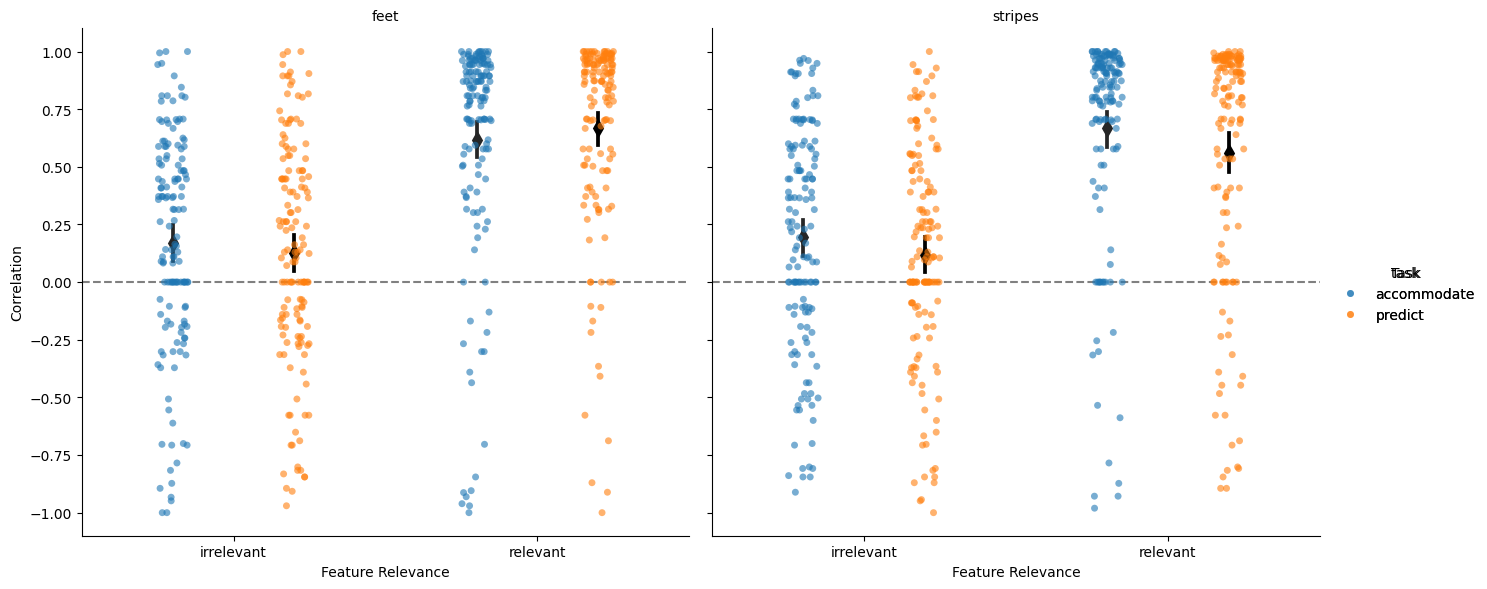

In [79]:
g = sns.catplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    col='feature_dimension',
    col_order=['feet', 'stripes'],   # <-- enforce left/right order
    kind='strip',
    dodge=True,
    jitter=.1,
    height=6,
    aspect=1,
    alpha = .6
)

g.map_dataframe(
    sns.pointplot,
    x='feature_relevance',
    y='correlation',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=1,
    legend=False
)

for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--')

g.set_axis_labels('Feature Relevance', 'Correlation')
g.set_titles('{col_name}')
g.add_legend(title='Task')

plt.savefig(
    os.path.join(outputdir, 'Figure10_FeatureCorrelation_ByTask_Relevance_FacetedByDimension.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

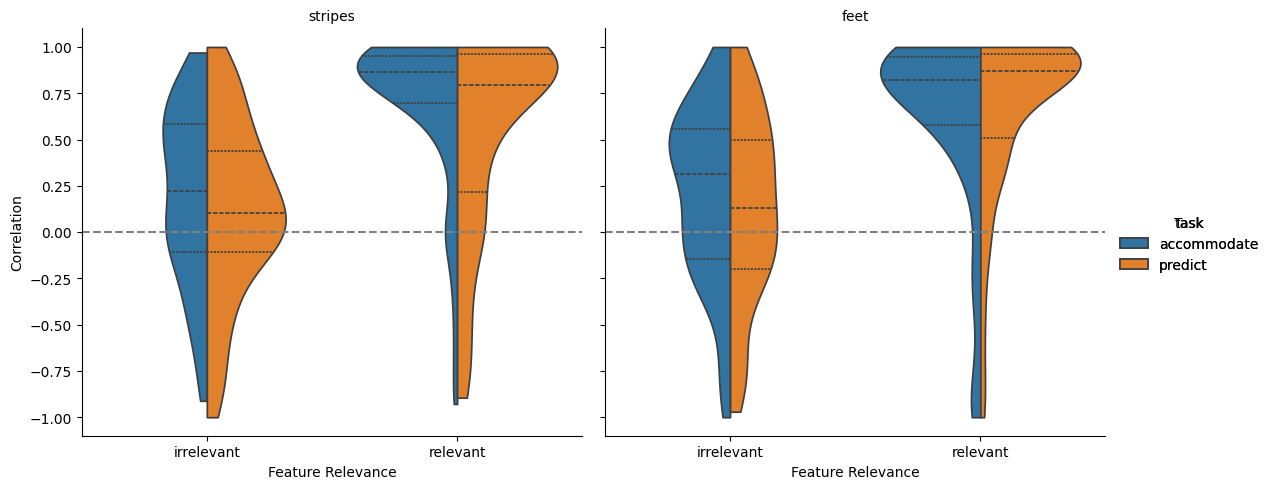

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    col='feature_dimension',   # <-- facet here
    kind='violin',
    split=True,
    inner='quartile',
    cut=0,
    height=5,
    aspect=1
)

# Add horizontal line at 0 to each facet
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--')

g.set_axis_labels('Feature Relevance', 'Correlation')
g.set_titles('{col_name}')  # shows feature_dimension in each panel
g.add_legend(title='Task')

plt.savefig(
    os.path.join(outputdir, 'Figure10_FeatureCorrelation_ByTask_Relevance_FacetedByDimension.png'),
    dpi=300
)

plt.show()

In [104]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "correlation ~ task * feature_relevance * feature_dimension",
    df_corr,
    groups=df_corr["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(
    os.path.join(outputdir, "Figure11_mixedlm_correlationStats.csv")
)

IndexError: index 840 is out of bounds for axis 0 with size 840

In [67]:
avg_corr_task_rel = df_corr.groupby(
    ['task'],
    as_index=False
)['correlation'].mean()

print(avg_corr_task_rel)
avg_corr_feature = df_corr.groupby(
    ['feature_dimension'],
    as_index=False
)['correlation'].mean()

print(avg_corr_feature)
avg_corr_relevance = df_corr.groupby(
    ['feature_relevance'],
    as_index=False
)['correlation'].mean()

print(avg_corr_relevance)

          task  correlation
0  accommodate     0.108902
1      predict     0.084416
  feature_dimension  correlation
0              feet     0.177890
1           stripes     0.015427
  feature_relevance  correlation
0        irrelevant     0.030805
1          relevant     0.162512


In [68]:
print(df_corr.tail(20))

      participant     task feature_dimension high_value feature_relevance  \
60  (predict, 11)  predict           stripes          W        irrelevant   
61  (predict, 11)  predict              feet          F          relevant   
62  (predict, 12)  predict           stripes          E          relevant   
63  (predict, 12)  predict              feet          F        irrelevant   
64  (predict, 13)  predict           stripes          W        irrelevant   
65  (predict, 13)  predict              feet          C          relevant   
66  (predict, 14)  predict           stripes          W          relevant   
67  (predict, 14)  predict              feet          C        irrelevant   
68  (predict, 15)  predict           stripes          W        irrelevant   
69  (predict, 15)  predict              feet          F          relevant   
70  (predict, 16)  predict           stripes          E          relevant   
71  (predict, 16)  predict              feet          F        irrelevant   

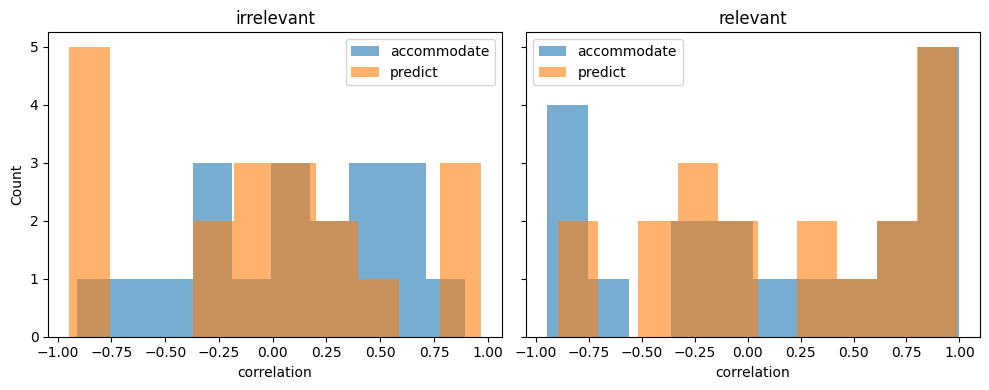

In [69]:
relevance_states = df_corr['feature_relevance'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(relevance_states),
    figsize=(5 * len(relevance_states), 4),
    sharey=True
)

if len(relevance_states) == 1:
    axes = [axes]

for ax, rel in zip(axes, relevance_states):
    for task in df_corr['task'].unique():
        values = df_corr.loc[
            (df_corr['feature_relevance'] == rel) &
            (df_corr['task'] == task),
            'correlation'
        ]
        ax.hist(values, bins=10, alpha=0.6, label=task)

    ax.set_title(rel)
    ax.set_xlabel("correlation")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure9_FeatureCorrelationByRelevanceAndTask.png'), dpi=300)
plt.show()

In [70]:
avg_corr_task_rel = df_corr.groupby(
    ['task', 'feature_relevance'],
    as_index=False
)['correlation'].mean()

print(avg_corr_task_rel)


          task feature_relevance  correlation
0  accommodate        irrelevant     0.099891
1  accommodate          relevant     0.117913
2      predict        irrelevant    -0.038280
3      predict          relevant     0.207111


In [71]:
avg_corr_task_rel = df_corr.groupby(
    ['task', 'feature_relevance'],
    as_index=False
)['abs_correlation'].mean()

print(avg_corr_task_rel)


          task feature_relevance  abs_correlation
0  accommodate        irrelevant         0.400888
1  accommodate          relevant         0.634929
2      predict        irrelevant         0.471264
3      predict          relevant         0.568596


In [381]:
import statsmodels.formula.api as smf

model = smf.ols(
    "abs_correlation ~ task * feature_relevance",
    df_corr
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        abs_correlation   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     86.09
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           9.63e-49
Time:                        13:20:09   Log-Likelihood:                -213.85
No. Observations:                 868   AIC:                             435.7
Df Residuals:                     864   BIC:                             454.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [384]:
nan_corrs = df_corr[pd.isna(df_corr['correlation'])]
#print(nan_corrs)
df_corr_clean = df_corr[pd.notna(df_corr['correlation'])].copy()



In [385]:
import statsmodels.formula.api as smf

md = smf.mixedlm(
    "correlation ~ task * feature_relevance",
    df_corr_clean,
    groups=df_corr_clean["participant"],  # random intercept per participant
    re_formula="~feature_relevance"  # random slopes if it converges
)
mdf = md.fit(method='lbfgs')
print(mdf.summary())
#mdf.summary().tables[1].to_csv(os.path.join(outputdir, "mixedlm_correlation.csv"))


                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           correlation
No. Observations:            868               Method:                       REML       
No. Groups:                  434               Scale:                        0.1909     
Min. group size:             2                 Log-Likelihood:               -646.7096  
Max. group size:             2                 Converged:                    Yes        
Mean group size:             2.0                                                        
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      0.177    0.031  5.658 0.000  0.116  0.238
task[T.predict]                               -

Supplementary: Irrelevant Feature Association with food amount and food consumption ratings

Supplementary Models Looking at Feature Dimension

In [412]:
import pandas as pd
from scipy.stats import chi2_contingency

# Loop through rows and determine model parameter score for each participant
participant_rows = []

for _, row in df_filtered.iterrows():
    feet_yes  = 1 if row['feet_discrete_slider.response'] == 'Yes' else 0
    color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0

    model_param_score = feet_yes + color_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],  # predict vs accommodate
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'irrelevant_dim': row['irrelevant_dim'],
        'feet_high': row['feet_high'],
        'overfit': model_param_score == 2  # overfit if both dimensions selected
    })

df_params = pd.DataFrame(participant_rows)

# Compare overfit vs not by condition
contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit      False  True 
task                     
accommodate    111     93
predict        140     64
Chi-square = 8.117
df = 1
p-value = 0.0044


model_param_score         task irrelevant_dim     0     1     2
0                  accommodate          color  11.0  41.0  43.0
1                  accommodate           feet  10.0  49.0  50.0
2                      predict          color  21.0  49.0  27.0
3                      predict           feet  14.0  56.0  37.0


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/2493775690.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'irrelevant_dim', 'model_param_score'])
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/2493775690.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  score_pivot = score_counts.pivot_table(


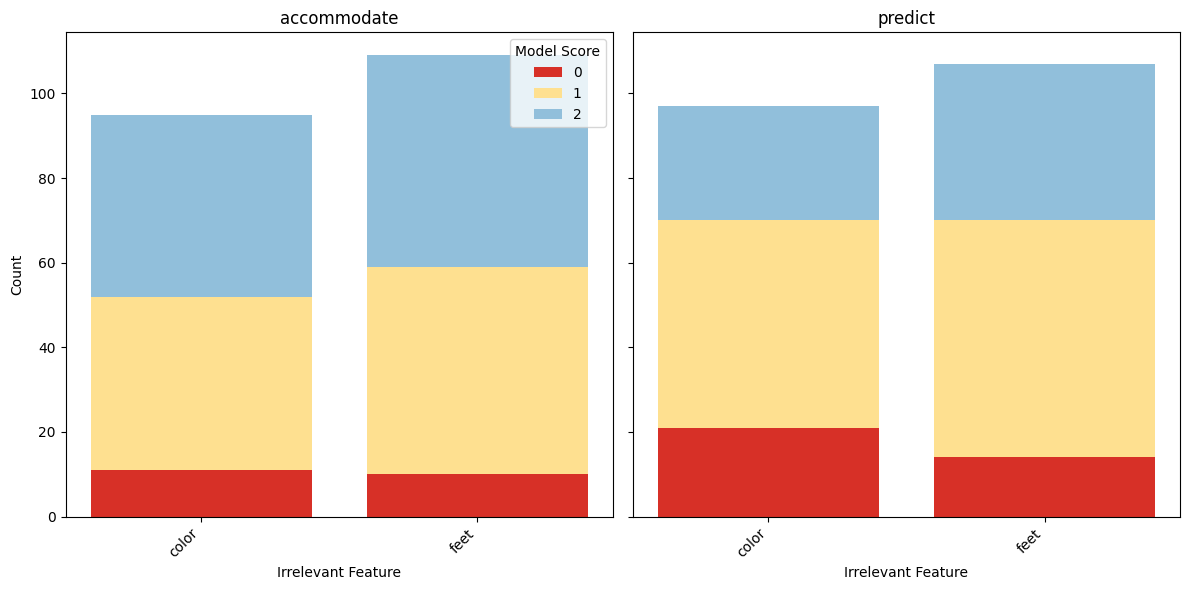

In [413]:
import numpy as np
import matplotlib.pyplot as plt
import os

df_params['task'] = df_params['task'].astype('category')

# Count occurrences of each model_param_score within each task × irrelevant feature
score_counts = (
    df_params
    .groupby(['task', 'irrelevant_dim', 'model_param_score'])
    .size()
    .reset_index(name='count')
)

# Pivot so each score becomes a column
score_pivot = score_counts.pivot_table(
    index=['task', 'irrelevant_dim'],
    columns='model_param_score',
    values='count',
    fill_value=0
).reset_index()

print(score_pivot)

tasks = df_params['task'].cat.categories
buckets = [0, 1, 2]   # now only 3 possible scores with 2 features
colors = ['#d73027', '#fee090', '#91bfdb']  # one color per score

# Create subplots, one per task
fig, axes = plt.subplots(1, len(tasks), figsize=(12, 6), sharey=True)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    # Filter for this task
    task_data = score_pivot[score_pivot['task'] == task].copy()

    x = np.arange(len(task_data))
    bottom = np.zeros(len(task_data))

    for i, b in enumerate(buckets):
        values = task_data[b] if b in task_data.columns else np.zeros(len(task_data))
        ax.bar(
            x,
            values,
            bottom=bottom,
            label=f"{b}" if ax == axes[0] else "",
            color=colors[i]
        )
        bottom += values.values if hasattr(values, "values") else values

    ax.set_xticks(x)
    ax.set_xticklabels(task_data['irrelevant_dim'], rotation=45, ha='right')
    ax.set_title(task)
    ax.set_xlabel("Irrelevant Feature")

axes[0].set_ylabel("Count")
axes[0].legend(title="Model Score")
plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure3ModelParamScoreDistributionByTaskAndIrrelevantFeature.png'))
plt.show()

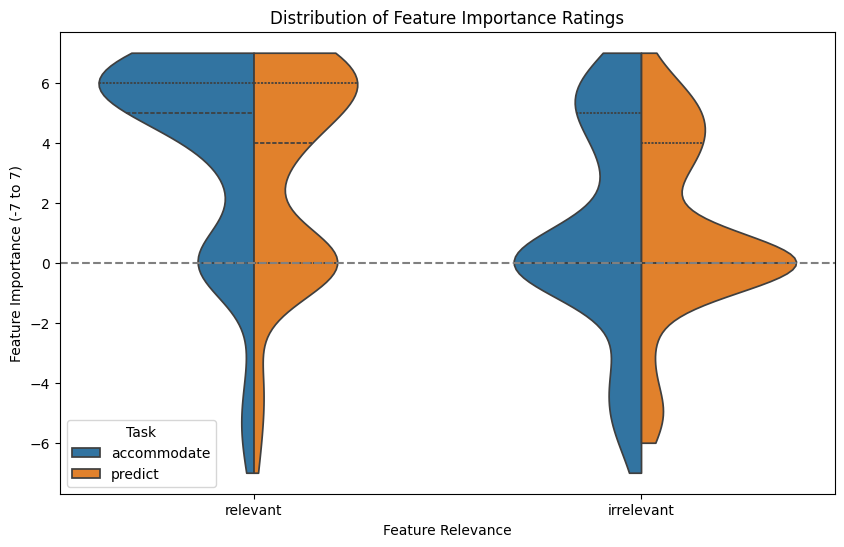

                          Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         feature_importance
No. Observations:           816             Method:                     REML              
No. Groups:                 408             Scale:                      11.0243           
Min. group size:            2               Log-Likelihood:             -2137.2539        
Max. group size:            2               Converged:                  Yes               
Mean group size:            2.0                                                           
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        3.897    0.232 16.764 0.000  3.441  4.353
task[T.predict]           

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [416]:
import pandas as pd
"""Reshape to long format with 1 row per participant x feature dimension"""
# Keep only necessary columns
cols_to_keep = [
    'participant', 'task', 
    'feet_importance', 'color_importance',
    'relevant_dim', 'irrelevant_dim', 'feet_high','color_high', 'feet_discrete_slider.response'
]

df_long = df_filtered[cols_to_keep].copy()

# Melt importance columns
df_long = df_long.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim', 'color_high', 'feet_high', 'feet_discrete_slider.response'],
    value_vars=['feet_importance', 'color_importance'],
    var_name='feature_dimension',
    value_name='feature_importance'
)

# Simplify feature dimension names
df_long['feature_dimension'] = df_long['feature_dimension'].str.replace('_importance','')

def get_relevance(row):
    if row['feature_dimension'] in [row['relevant_dim']]:
        return 'relevant'
    else:
        return 'irrelevant'

df_long['feature_relevance'] = df_long.apply(get_relevance, axis=1)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
#plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()
import statsmodels.formula.api as smf

#T. Predict: tests task differences for irrelevant features
#interaction: tests whether the predict v accommodate effect changes across relevant vs irrelevant features
#The predict vs. accommodate gap is 1.8 units larger for relevant features than for irrelevant features.
#Predict v accommodate ratings are close for relevant features, but far apart for irrelevant
df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['relevant', 'irrelevant'], ordered=False)

model = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())
#model.summary().tables[1].to_csv(os.path.join(outputdir, "Figure5mixedlm_featureimportanceStats.csv"))


In [409]:
print(df_long)

     participant         task relevant_dim irrelevant_dim color_high  \
0              1  accommodate         feet          color          Y   
1              2  accommodate         feet          color          Y   
2              3  accommodate        color           feet          Y   
3              5  accommodate         feet          color          Y   
4              6  accommodate        color           feet          Y   
..           ...          ...          ...            ...        ...   
811          430      predict        color           feet          Y   
812          431      predict         feet          color          Y   
813          432      predict         feet          color          Y   
814          433      predict        color           feet          Y   
815          434      predict        color           feet          Y   

    feet_high feet_discrete_slider.response feature_dimension  \
0           F                            No              feet   
1    

In [417]:
df_long.to_csv(os.path.join(outputdirCleaned, 'df_long_for_R-Study3Filtered.csv'), index=False)

In [ ]:
import ast
import matplotlib.pyplot as plt
#Calculate reported food amounts during testing
def AverageFoodCalclator(participants_to_use):
    df_subset = df_combined[df_combined['participant'].isin(participants_to_use)]
    all_trials = []
    for i in df_subset['participant']:
        ratings     = df_subset[df_subset['participant'] == i]['testing_responses'].iloc[0]
        categories = df_subset[df_subset['participant'] == i]['testing_categories'].iloc[0]
        task = df_subset[df_subset['participant'] == i]['task'].iloc[0]
        row = df_subset[df_subset['participant'] == i].iloc[0]
        tail_yes  = 1 if row['tail_discrete_slider.response']  == 'Yes' else 0
        shape_yes = 1 if row['shape_discrete_slider.response'] == 'Yes' else 0
        color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0
        num_features_relevant = tail_yes + shape_yes + color_yes
        df_participant = pd.DataFrame(list(zip(
            [i]*len(ratings),  # Repeat participant ID and task to match the number of ratings
            ratings,
            [task]*len(ratings), # Repeat participant ID and task to match the number of ratings
            categories,
            [num_features_relevant]*len(ratings)
        )), columns=['participant', 'ratings', 'task', 'category', 'num_features_relevant'])
        all_trials.append(df_participant)
    df_average = pd.concat(all_trials, ignore_index=True)
    avg_ratings_cond = df_average.groupby(['task', 'category'])['ratings'].mean()
    return df_average, avg_ratings_cond

participants_to_use = df_combined['participant'].tolist()
df_average, avg_rating_cond = AverageFoodCalclator(participants_to_use)
print(avg_rating_cond)
print(df_average)
# Group by task, category, and num_features_relevant
model_parameter_score = df_average.groupby(
    ['num_features_relevant']
)['ratings'].mean().reset_index()

print(model_parameter_score)
# Group by task, category, and num_features_relevant
avg_ratings_cond_by_relevance = df_average.groupby(
    ['task', 'category', 'num_features_relevant']
)['ratings'].mean().reset_index()


print(avg_ratings_cond_by_relevance)
category_order = ['low', 'medium', 'high']
avg_ratings_cond_by_relevance['category'] = pd.Categorical(
    avg_ratings_cond_by_relevance['category'],
    categories=category_order,
    ordered=True
)
import seaborn as sns
sns.catplot(
    data=avg_ratings_cond_by_relevance,
    x='category', y='ratings',
    hue='num_features_relevant', col='task',
    kind='bar', palette='Set2'
)
plt.show()

<Axes: xlabel='category', ylabel='ratings'>

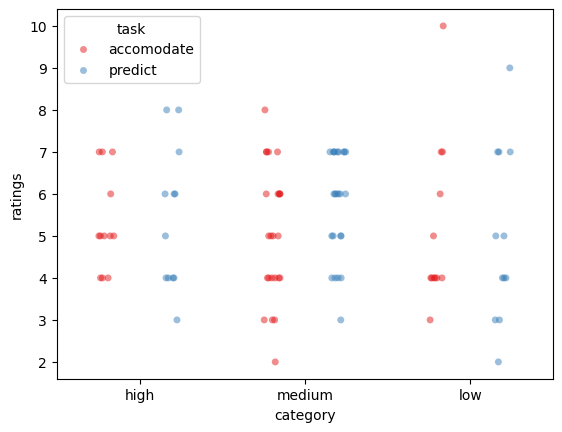

In [ ]:
sns.stripplot(data=df_average, x='category', y='ratings', hue='task', 
              palette='Set1', dodge=True, jitter=True, color='black', alpha=0.5)

In [ ]:
print(df_average.head(20))

    participant  ratings        task category  num_features_relevant
0             1      6.0  accomodate     high                      1
1             1      5.0  accomodate   medium                      1
2             1      3.0  accomodate      low                      1
3             1      5.0  accomodate   medium                      1
4             1      5.0  accomodate   medium                      1
5             1      7.0  accomodate     high                      1
6             1      4.0  accomodate      low                      1
7             1      4.0  accomodate   medium                      1
8             2      5.0  accomodate   medium                      2
9             2      3.0  accomodate   medium                      2
10            2      5.0  accomodate     high                      2
11            2      7.0  accomodate      low                      2
12            2      7.0  accomodate     high                      2
13            2      5.0  accomoda

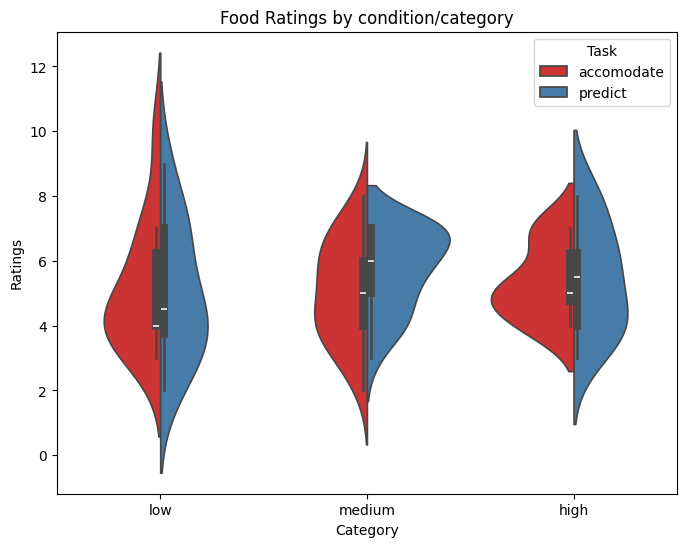

In [ ]:
order = ['low', 'medium', 'high']
# Violin plot: ratings by category, separated by task
plt.figure(figsize=(8,6))
sns.violinplot(
    data=df_average,
    x='category',       # x-axis: categories
    y='ratings',        # y-axis: ratings
    hue='task',         # split by task
    split=True,         # split the violins by task
    palette='Set1',
    inner='box',    # show box plot of data inside
    order = order
)

plt.ylabel('Ratings')
plt.xlabel('Category')
plt.title('Food Ratings by condition/category')
plt.legend(title='Task')
#plt.savefig(f'{study}Plots/ViolinRatings.png', bbox_inches='tight')
plt.show()

In [ ]:
def decode_rel(rel_values):
    """
    rel_values: Series of lists of rel codes
    """

    flat_vals = []
    for v in rel_values:
        if isinstance(v, list):
            flat_vals.extend(v)

    flat_vals = pd.Series(flat_vals).dropna().unique()

    if len(flat_vals) == 0:
        return pd.Series({'feature_relevance': np.nan})

    # irrelevant: only I-codes
    if all(v.startswith('I') for v in flat_vals):
        return pd.Series({'feature_relevance': 'irrelevant'})

    # relevant: contains R or L
    if any(v.startswith(('R', 'L')) for v in flat_vals):
        return pd.Series({'feature_relevance': 'relevant'})

    raise ValueError(f"Unexpected rel codes: {flat_vals}")


feature_relevance_rows = []

for (cond, task), subdf in df_combined.groupby(['conditionOrder', 'task']):
    for feat in ['tail', 'color', 'shape']:
        relevance = decode_rel(subdf[f'training_{feat}'])

        feature_relevance_rows.append({
            'conditionOrder': cond,
            'task': task,
            'feature_dimension': feat,
            'feature_relevance': relevance
        })

df_feature_relevance = pd.DataFrame(feature_relevance_rows)
print(df_feature_relevance)

    conditionOrder        task feature_dimension  \
0                1  accomodate              tail   
1                1  accomodate             color   
2                1  accomodate             shape   
3                1     predict              tail   
4                1     predict             color   
5                1     predict             shape   
6                2  accomodate              tail   
7                2  accomodate             color   
8                2  accomodate             shape   
9                2     predict              tail   
10               2     predict             color   
11               2     predict             shape   
12               3  accomodate              tail   
13               3  accomodate             color   
14               3  accomodate             shape   
15               3     predict              tail   
16               3     predict             color   
17               3     predict             shape   
18          

In [ ]:
features = ['shape', 'color', 'tail']
long_rows = []

for _, row in df_combined.iterrows():
    for feat in features:
        long_rows.append({
            'participant': row['participant'],
            'conditionOrder': row['conditionOrder'],
            'task': row['task'],
            'feature_dimension': feat,

            'discrete': row[f'{feat}_discrete_slider.response'],
            'direction': row[f'{feat}_direction_slider.response'],
            'continuous': row[f'{feat}_continuous_slider.response'],
        })

df_long = pd.DataFrame(long_rows)
print(df_long.head(10))

   participant  conditionOrder        task feature_dimension discrete  \
0            1               4  accomodate             shape      Yes   
1            1               4  accomodate             color       No   
2            1               4  accomodate              tail       No   
3            2               1  accomodate             shape       No   
4            2               1  accomodate             color      Yes   
5            2               1  accomodate              tail      Yes   
6            3               3  accomodate             shape      Yes   
7            3               3  accomodate             color      Yes   
8            3               3  accomodate              tail      Yes   
9            4               2  accomodate             shape      Yes   

       direction  continuous  
0         Square         5.0  
1            NaN         NaN  
2            NaN         NaN  
3            NaN         NaN  
4           Blue         4.0  
5  Having 

In [ ]:
df_long = df_long.merge(
    df_feature_relevance,
    on=['conditionOrder', 'task', 'feature_dimension'],
    how='left'
)
print(df_long.head(21))

    participant  conditionOrder        task feature_dimension discrete  \
0             1               4  accomodate             shape      Yes   
1             1               4  accomodate             color       No   
2             1               4  accomodate              tail       No   
3             2               1  accomodate             shape       No   
4             2               1  accomodate             color      Yes   
5             2               1  accomodate              tail      Yes   
6             3               3  accomodate             shape      Yes   
7             3               3  accomodate             color      Yes   
8             3               3  accomodate              tail      Yes   
9             4               2  accomodate             shape      Yes   
10            4               2  accomodate             color      Yes   
11            4               2  accomodate              tail      Yes   
12            5               2     pr